# Challenge INF4248 — Prédiction des cas de Paludisme au Cameroun
## Approche Expert : Prétraitement Rigoureux · EDA Profonde · Multi-Modèles · Multi-Cible · Robustesse Temporelle

---

**Contexte.** Les données couvrent **9 504 observations** (198 districts × 4 années × 12 mois, 2021–2024) et incluent des variables climatiques (précipitations, température, humidité), démographiques (population par tranche d'âge) et d'interventions de santé publique (MILDA, TPI). L'objectif est de prédire 4 cibles de comptage :

| Cible | Description | Population |
|---|---|---|
| `severe_under5` | Cas graves confirmés | Enfants < 5 ans |
| `severe_pregnant` | Cas graves confirmés | Femmes enceintes |
| `severe_5plus` | Cas graves confirmés | Population 5 ans et + |
| `simple_cases` | Cas simples confirmés | Population générale *(non désagrégée)* |

**Plan du notebook**

1. [Imports & Configuration](#1)
2. [Chargement & Audit de qualité](#2)
3. [Prétraitement & Ingénierie des variables](#3)
4. [Analyse Exploratoire Approfondie (EDA)](#4)
5. [Préparation de la modélisation (variables, cibles, anti-fuite)](#5)
6. [Stratégie de validation & split](#6)
7. [Transformation des cibles (log1p)](#7)
8. [Modélisation complète : Dummy → Ridge → RF → HGB → Stacking](#8)
9. [Prédiction Multi-Cible (RegressorChain & MultiOutput)](#9)
10. [Stabilité des modèles (variance inter-plis)](#10)
11. [Robustesse temporelle (généralisation 2024)](#11)
12. [Analyse fine des erreurs (par région, mois, année)](#12)
13. [Importance des variables & interprétation par catégorie](#13)
14. [Intervalles de prédiction (quantile regression)](#14)
15. [Synthèse des résultats, limites & recommandations](#15)



<a id="1"></a>
## 1. Imports & Configuration

In [40]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    RandomizedSearchCV, GroupKFold, TimeSeriesSplit,
    train_test_split, cross_validate
)
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─── Reproductibilité & affichage ────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

DATA_PATH = '.\Data_Palu.xlsx'
print("✓ Imports OK — scikit-learn", __import__('sklearn').__version__)

✓ Imports OK — scikit-learn 1.8.0


<a id="2"></a>
## 2. Chargement & Audit de qualité

Avant tout prétraitement, Nous réalisons un **audit complet et documenté** de la donnée brute : dimensions, types, valeurs manquantes, doublons structurels, complétude du panel et outliers. Un modèle entraîné sur des données non auditées donne une *fausse impression de fiabilité*.

In [41]:
RAW = pd.read_excel(DATA_PATH)
print(f"Dimensions brutes : {RAW.shape[0]:,} lignes × {RAW.shape[1]} colonnes")
RAW.head(3)

Dimensions brutes : 9,504 lignes × 28 colonnes


,Région,District,Annee,Mois,PRECTOTCORR,PRECTOTCORR_SUM,RH2M,T2M,T2M_MAX,T2M_MIN,WD10M,WS10M,ZAE,Cas graves confirmes - 5 ans et plus,Cas graves confirmes - Femmes enceintes,Cas graves confirmes - Moins 5 ans,Cas simples confirmes,Doses - TPIn 1,Doses - TPIn 2,Doses - TPIn 3,Doses de TPI1_fe,Doses de TPI3_fe,MILDA distribuees - Femmes enceintes,MILDA distribuees - Nourrissons,Pregnant_Women,SurvivingInfants,12_23month,DistrictPopulation
0,Adamaoua,bankim,2021,Avril,5.202,5.202,76.202,25.393,33.413,19.493,191.178,2.007,ZAE2_ZAE5,0,0,0,0,0,0,0,0,0,0,0,4905.000,4510.000,4108.000,118390.000
1,Adamaoua,bankim,2021,Août,6.693,6.693,86.437,23.016,28.610,19.165,250.913,2.068,ZAE2_ZAE5,0,0,0,0,0,0,0,0,0,0,0,4905.000,4510.000,4108.000,118390.000
2,Adamaoua,bankim,2021,Décembre,2.000,2.000,67.939,24.294,31.500,17.980,130.521,2.461,ZAE2_ZAE5,0,0,0,0,0,0,0,0,0,0,0,4905.000,4510.000,4108.000,118390.000


In [42]:
# ── 2.1 Renommage en snake_case (traçable / dictionnaire des données) ──────
RENAME = {
    'Région': 'region', 'District': 'district', 'Annee': 'annee', 'Mois': 'mois',
    'PRECTOTCORR': 'prectotcorr', 'PRECTOTCORR_SUM': 'prectotcorr_sum',
    'RH2M': 'rh2m', 'T2M': 't2m', 'T2M_MAX': 't2m_max', 'T2M_MIN': 't2m_min',
    'WD10M': 'wd10m', 'WS10M': 'ws10m', 'ZAE': 'zae',
    'Cas graves confirmes - 5 ans et plus':   'severe_5plus',
    'Cas graves confirmes - Femmes enceintes': 'severe_pregnant',
    'Cas graves confirmes - Moins 5 ans':      'severe_under5',
    'Cas simples confirmes':                   'simple_cases',
    'Doses - TPIn 1': 'tpin1_doses', 'Doses - TPIn 2': 'tpin2_doses',
    'Doses - TPIn 3': 'tpin3_doses', 'Doses de TPI1_fe': 'tpi1_fe_doses',
    'Doses de TPI3_fe': 'tpi3_fe_doses',
    'MILDA distribuees - Femmes enceintes': 'milda_fe',
    'MILDA distribuees - Nourrissons': 'milda_nourrissons',
    'Pregnant_Women': 'pregnant_women', 'SurvivingInfants': 'surviving_infants',
    '12_23month': 'm12_23', 'DistrictPopulation': 'district_population',
}
df = RAW.rename(columns=RENAME).copy()
assert set(RENAME.values()) == set(df.columns), "Renommage incomplet — vérifier RENAME"
print("✓ Colonnes renommées.")

✓ Colonnes renommées.


In [43]:
# ── 2.2 Valeurs manquantes ────────────────────────────────────────────────
print("═"*55)
print("AUDIT 1 — Valeurs manquantes")
print("═"*55)
missing = df.isna().sum()
print(f"Total cellules manquantes : {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("→ Aucune valeur manquante. ✓")

═══════════════════════════════════════════════════════
AUDIT 1 — Valeurs manquantes
═══════════════════════════════════════════════════════
Total cellules manquantes : 0
→ Aucune valeur manquante. ✓


In [44]:
# ── 2.3 Complétude du panel ────────────────────────────────────────────────
print("═"*55)
print("AUDIT 2 — Structure du panel (district × année × mois)")
print("═"*55)
print(f"Années couvertes          : {sorted(df['annee'].unique())}")
print(f"Nombre de districts       : {df['district'].nunique()}")
print(f"Nombre de régions         : {df['region'].nunique()}")
panel_check = df.groupby('district')['annee'].nunique()
print(f"Districts avec < 4 années : {(panel_check < 4).sum()}")
dup = df.duplicated(subset=['district','annee','mois']).sum()
print(f"Doublons (dist×an×mois)   : {dup}")
# Lignes attendues = 198 districts × 4 ans × 12 mois = 9 504
print(f"Lignes attendues          : {df['district'].nunique() * 4 * 12}")
print(f"Lignes réelles            : {len(df)}")

═══════════════════════════════════════════════════════
AUDIT 2 — Structure du panel (district × année × mois)
═══════════════════════════════════════════════════════
Années couvertes          : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Nombre de districts       : 198
Nombre de régions         : 10
Districts avec < 4 années : 0
Doublons (dist×an×mois)   : 0
Lignes attendues          : 9504
Lignes réelles            : 9504


In [45]:
# ── 2.4 Colonne dupliquée ─────────────────────────────────────────────────
print("═"*55)
print("AUDIT 3 — Colonne dupliquée (PRECTOTCORR vs PRECTOTCORR_SUM)")
print("═"*55)
ecart = (df['prectotcorr'] - df['prectotcorr_sum']).abs().max()
print(f"Écart maximal absolu : {ecart}")
print("→ Colonnes identiques. Suppression de prectotcorr_sum.")
df.drop(columns=['prectotcorr_sum'], inplace=True)

═══════════════════════════════════════════════════════
AUDIT 3 — Colonne dupliquée (PRECTOTCORR vs PRECTOTCORR_SUM)
═══════════════════════════════════════════════════════
Écart maximal absolu : 0.0
→ Colonnes identiques. Suppression de prectotcorr_sum.


In [46]:
# ── 2.5 Outliers sur les variables explicatives ───────────────────────────
print("═"*55)
print("AUDIT 4 — Outliers variables explicatives")
print("═"*55)

# tpin1_doses : valeur aberrante extrême (8 225 180 vs médiane ≈ 0)
seuil_tpin1 = 10_000
mask_out = df['tpin1_doses'] > seuil_tpin1
print(f"tpin1_doses > {seuil_tpin1:,} : {mask_out.sum()} observation(s)")
if mask_out.sum() > 0:
    print(df.loc[mask_out, ['region','district','annee','mois','tpin1_doses']])
    med_propre = df.loc[~mask_out, 'tpin1_doses'].median()
    df.loc[mask_out, 'tpin1_doses'] = med_propre
    print(f"→ Remplacée par la médiane ({med_propre:.1f}). Nouveau max : {df['tpin1_doses'].max():.1f}")

═══════════════════════════════════════════════════════
AUDIT 4 — Outliers variables explicatives
═══════════════════════════════════════════════════════
tpin1_doses > 10,000 : 1 observation(s)
          region district  annee     mois  tpin1_doses
6418  Nord-Ouest   batibo   2023  Octobre      8225180
→ Remplacée par la médiane (0.0). Nouveau max : 7712.0


In [47]:
# ── 2.6 Distribution des cibles : résumé statistique ─────────────────────
print("═"*55)
print("AUDIT 5 — Distribution des variables cibles")
print("═"*55)
TARGETS_RAW = ['severe_under5','severe_pregnant','severe_5plus','simple_cases']
summary = []
for c in TARGETS_RAW:
    s = df[c]
    summary.append({'Cible': c, 'Min': s.min(), 'Médiane': s.median(),
                    'Moyenne': round(s.mean(),2), 'Max': s.max(),
                    '% zéros': f"{(s==0).mean():.1%}",
                    'Asymétrie': round(s.skew(),2)})
pd.DataFrame(summary).set_index('Cible')

═══════════════════════════════════════════════════════
AUDIT 5 — Distribution des variables cibles
═══════════════════════════════════════════════════════


,Min,Médiane,Moyenne,Max,% zéros,Asymétrie
Cible,,,,,,
severe_under5,0,0.000,55.200,1043,60.7%,2.830
severe_pregnant,0,0.000,17.910,329,60.9%,2.820
severe_5plus,0,0.000,103.440,1914,60.7%,3.460
simple_cases,0,0.000,316.770,8023,60.7%,3.050


**Remarque: inflation de zéros et forte asymétrie.** Les quatre cibles présentent \~61 % de zéros et une asymétrie de Pearson élevée (2.8 à 3.5). Ce profil est typique des données de surveillance épidémiologique désagrégées au niveau district-mois : beaucoup de petits districts n'enregistrent aucun cas confirmé certains mois. Cette observation commande deux décisions techniques importantes (détaillées en sections 7 et 8) :
- **Transformation `log1p`** des cibles avant modélisation pour compresser l'asymétrie et stabiliser la variance résiduelle.
- **Choix de métriques d'évaluation multiples** : MAE (robuste aux extremes), RMSE (pénalise les grosses erreurs), R² (variance expliquée) — aucune ne suffit seule ici.

<a id="3"></a>
## 3. Prétraitement & Ingénierie des variables

### 3.1 Encodage temporel cyclique et ordinal du district

In [48]:
# ── Encodage du mois ──────────────────────────────────────────────────────
MONTH_MAP = {
    'Janvier':1,'Février':2,'Mars':3,'Avril':4,'Mai':5,'Juin':6,
    'Juillet':7,'Août':8,'Septembre':9,'Octobre':10,'Novembre':11,'Décembre':12
}
df['month_num'] = df['mois'].map(MONTH_MAP)
assert df['month_num'].isna().sum() == 0, "Mois non reconnu"

# Encodage cyclique : Décembre et Janvier doivent être adjacents dans l'espace des features
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Encodage ordinal stable du district
districts_sorted = sorted(df['district'].unique())
district_map = {d: i for i, d in enumerate(districts_sorted)}
df['district_encoded'] = df['district'].map(district_map)

print("✓ Encodages temporels et district créés.")
df[['mois','month_num','month_sin','month_cos','district','district_encoded']].head(4)

✓ Encodages temporels et district créés.


,mois,month_num,month_sin,month_cos,district,district_encoded
0,Avril,4,0.866,-0.500,bankim,23
1,Août,8,-0.866,-0.500,bankim,23
2,Décembre,12,-0.000,1.000,bankim,23
3,Février,2,0.866,0.500,bankim,23


### 3.2 Zone agro-écologique (ZAE) et région

La colonne `ZAE` contient 14 combinaisons distinctes (ex. `ZAE1_ZAE2_ZAE3`); un district peut chevaucher plusieurs zones. On la décompose en **5 indicatrices binaires** (présence/absence par zone) plutôt qu'un one-hot sur la chaîne complète, ce qui préserve l'information de chevauchement et réduit la dimensionnalité.

In [49]:
# ── ZAE → indicatrices binaires par zone ─────────────────────────────────
print("ZAE — 14 combinaisons uniques :")
print(sorted(df['zae'].unique()))

for z in range(1, 6):
    df[f'zae{z}'] = df['zae'].str.contains(f'ZAE{z}\\b', regex=True).astype(int)

print("\nDistribution des indicatrices ZAE (nombre d'observations) :")
print(df[[f'zae{z}' for z in range(1,6)]].sum().to_frame('n_obs').T)

# ── Région → one-hot (10 modalités) ──────────────────────────────────────
region_dummies = pd.get_dummies(df['region'], prefix='reg', dtype=int)
df = pd.concat([df, region_dummies], axis=1)
print(f"\n✓ {len(region_dummies.columns)} colonnes de région créées : {list(region_dummies.columns)}")

ZAE — 14 combinaisons uniques :
['ZAE1', 'ZAE1_ZAE2', 'ZAE1_ZAE2_ZAE3', 'ZAE1_ZAE2_ZAE5', 'ZAE1_ZAE3', 'ZAE1_ZAE5', 'ZAE2', 'ZAE2_ZAE3', 'ZAE2_ZAE5', 'ZAE3', 'ZAE3_ZAE4', 'ZAE4', 'ZAE4_ZAE5', 'ZAE5']

Distribution des indicatrices ZAE (nombre d'observations) :
       zae1  zae2  zae3  zae4  zae5
n_obs  2112  1968  2352  2112   960

✓ 10 colonnes de région créées : ['reg_Adamaoua', 'reg_Centre', 'reg_Est', 'reg_Extreme-Nord', 'reg_Littoral', 'reg_Nord', 'reg_Nord-Ouest', 'reg_Ouest', 'reg_Sud', 'reg_Sud-Ouest']


### 3.3 Variables dérivées démographiques et de sévérité

>  **Les données montrent** : `total_severe_cases`, `total_cases`, `severe_case_ratio` et `severe_threshold_alert` sont des **agrégats directs des cibles**. Ils sont créés ici pour l'EDA mais seront **strictement exclus des features de modélisation** (section 5).

In [50]:
# ── Population ────────────────────────────────────────────────────────────
df['under_2_population'] = df['surviving_infants'] + df['m12_23']

# ── Agrégats de sévérité (EDA uniquement — exclus du modeling) ────────────
df['total_severe_cases']   = df['severe_5plus'] + df['severe_pregnant'] + df['severe_under5']
df['total_simple_cases']   = df['simple_cases']
df['total_cases']          = df['total_severe_cases'] + df['total_simple_cases']
df['severe_case_ratio']    = np.where(df['total_cases'] > 0,
                                       df['total_severe_cases'] / df['total_cases'], 0)
df['severe_threshold_alert'] = (df['severe_case_ratio'] > 0.15).astype(int)

print("✓ Variables de sévérité créées (réservées à l'EDA).")
print(f"  Districts avec alerte sévérité (ratio > 15%) : {df['severe_threshold_alert'].mean():.1%} des obs.")

✓ Variables de sévérité créées (réservées à l'EDA).
  Districts avec alerte sévérité (ratio > 15%) : 36.8% des obs.


### 3.4 Variables climatiques décalées (lags) et fenêtres glissantes

Le cycle biologique du moustique anophèle introduit un **décalage naturel** entre les conditions climatiques et l'apparition des cas cliniques (7–21 jours d'incubation parasitaire + développement larvaire). On crée des décalages de 1 et 2 mois (`_lag1`, `_lag2`) et une moyenne glissante 3 mois (`_roll3`) **uniquement sur le passé** (`.shift(1)` avant `.rolling()`) — aucune information future ne doit contaminer le signal.

In [51]:
df = df.sort_values(['district','annee','month_num']).reset_index(drop=True)

LAG_FEATURES = ['prectotcorr','t2m','t2m_max','t2m_min','rh2m','milda_fe','milda_nourrissons']

for feat in LAG_FEATURES:
    for lag in [1, 2]:
        df[f'{feat}_lag{lag}'] = df.groupby('district')[feat].shift(lag)

# Moyenne glissante pluviométrie (passé uniquement)
df['prectotcorr_roll3'] = (
    df.groupby('district')['prectotcorr']
      .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

# Cumul précipitations 6 mois (signal de saison longue)
df['prectotcorr_roll6'] = (
    df.groupby('district')['prectotcorr']
      .transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
)

lag_cols = [f'{f}_lag{l}' for f in LAG_FEATURES for l in [1,2]] + ['prectotcorr_roll3','prectotcorr_roll6']
n_nan = df[lag_cols].isna().sum().sum()
total = df.shape[0] * len(lag_cols)
print(f"NaN résiduels (1–2 premières obs/district) : {n_nan} / {total} ({n_nan/total:.1%})")

# Imputation par médiane globale (observations de début de série uniquement)
for c in lag_cols:
    df[c] = df[c].fillna(df[c].median())
print("✓ Lags & rolling créés. NaN résiduels après imputation :", df[lag_cols].isna().sum().sum())

NaN résiduels (1–2 premières obs/district) : 4554 / 152064 (3.0%)
✓ Lags & rolling créés. NaN résiduels après imputation : 0


### 3.5 Features d'interaction et de couverture d'intervention

On construit des ratios de **couverture** (doses / population cible) plutôt que des comptages bruts : un district plus peuplé reçoit mécaniquement plus de doses mais la couverture reste comparable. On ajoute également l'**amplitude thermique** (T_max − T_min), corrélée à la densité de moustiques, et des **interactions climatiques** pertinentes.

In [52]:
# ── Variables climatiques dérivées ─────────────────────────────────────────
df['temp_range']        = df['t2m_max'] - df['t2m_min']
df['temp_range_lag1']   = df['t2m_max_lag1'] - df['t2m_min_lag1']

# Interaction température × humidité → confort vecteur
df['heat_humidity_idx'] = df['t2m'] * df['rh2m'] / 100

# ── Couvertures d'intervention (ratio dose/population) ─────────────────────
EPS = 1.0  # évite division par zéro pour très petites populations
df['tpi1_fe_coverage']          = df['tpi1_fe_doses']    / (df['pregnant_women']    + EPS)
df['tpi3_fe_coverage']          = df['tpi3_fe_doses']    / (df['pregnant_women']    + EPS)
df['milda_fe_coverage']         = df['milda_fe']         / (df['pregnant_women']    + EPS)
df['tpin1_coverage']            = df['tpin1_doses']      / (df['surviving_infants'] + EPS)
df['tpin2_coverage']            = df['tpin2_doses']      / (df['surviving_infants'] + EPS)
df['tpin3_coverage']            = df['tpin3_doses']      / (df['surviving_infants'] + EPS)
df['milda_nourrissons_coverage'] = df['milda_nourrissons'] / (df['surviving_infants'] + EPS)

# ── Agrégats d'intervention ────────────────────────────────────────────────
df['milda_total'] = df['milda_fe'] + df['milda_nourrissons']
df['tpi_total']   = (df['tpin1_doses'] + df['tpin2_doses'] + df['tpin3_doses']
                    + df['tpi1_fe_doses'] + df['tpi3_fe_doses'])
df['tpi_fe_total']  = df['tpi1_fe_doses'] + df['tpi3_fe_doses']
df['tpin_total']    = df['tpin1_doses'] + df['tpin2_doses'] + df['tpin3_doses']

# Densité démographique proxy (pop/km² non disponible → pop normalisée)
df['pop_density_proxy'] = df['district_population'] / (df['district_population'].max())

print(f"✓ Features d'interaction et de couverture créées.")
print(f"  Dimensions finales du DataFrame : {df.shape}")

✓ Features d'interaction et de couverture créées.
  Dimensions finales du DataFrame : (9504, 83)


<a id="4"></a>
## 4. Analyse Exploratoire Approfondie (EDA)

### 4.1 Distribution des cibles et inflation de zéros

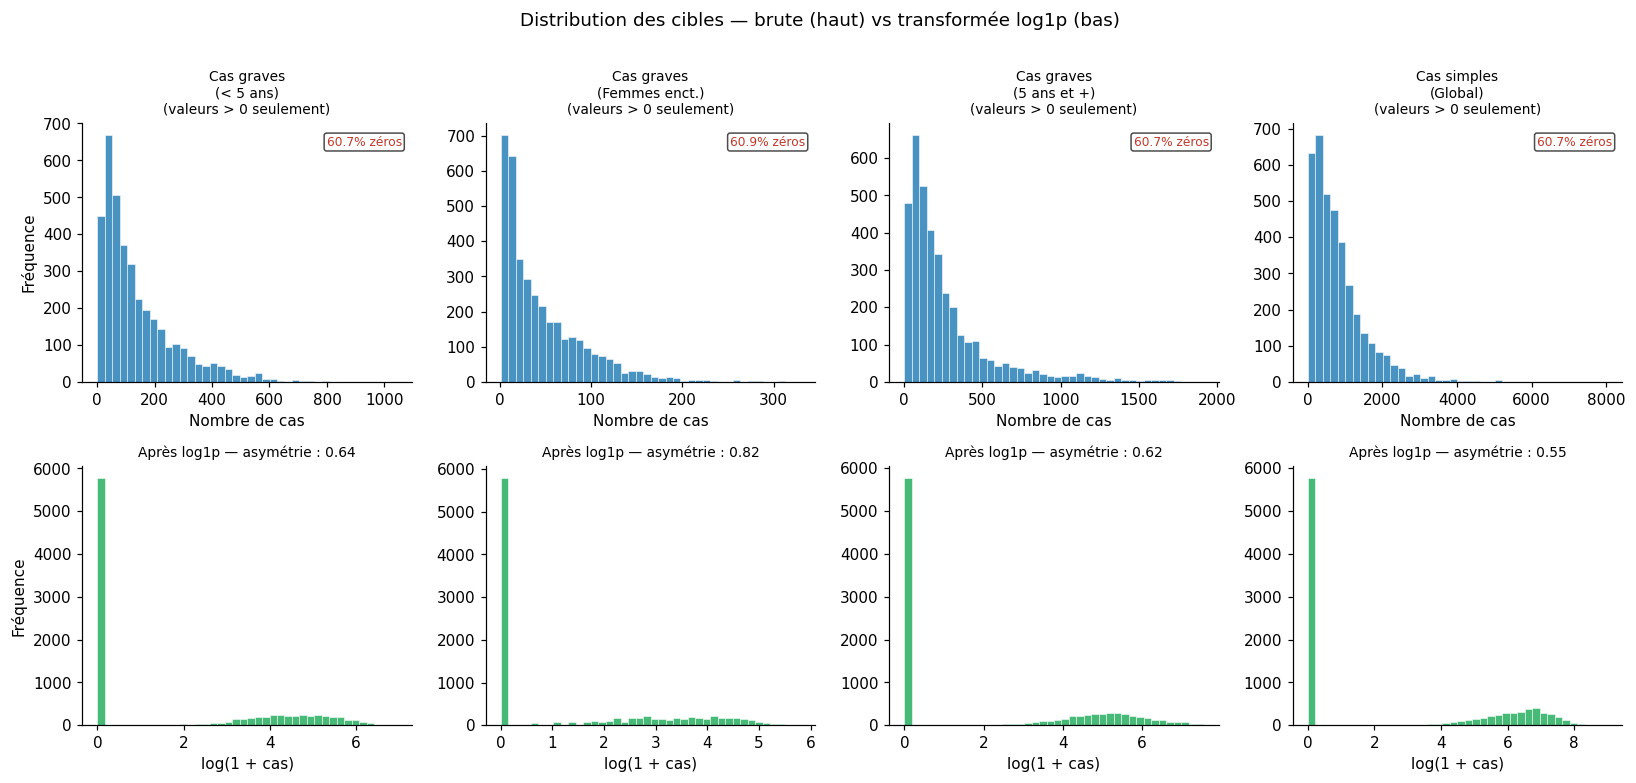

In [53]:
TARGETS = ['severe_under5','severe_pregnant','severe_5plus','simple_cases']
TARGETS_LABELS = ['Cas graves\n(< 5 ans)', 'Cas graves\n(Femmes enct.)',
                   'Cas graves\n(5 ans et +)', 'Cas simples\n(Global)']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, (target, label) in enumerate(zip(TARGETS, TARGETS_LABELS)):
    vals = df[target]
    nonzero = vals[vals > 0]

    ax_hist = axes[0, i]
    ax_hist.hist(nonzero, bins=40, color='#2980b9', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax_hist.set_title(f'{label}\n(valeurs > 0 seulement)', fontsize=9)
    ax_hist.set_xlabel('Nombre de cas')
    ax_hist.set_ylabel('Fréquence' if i == 0 else '')
    ax_hist.text(0.97, 0.95, f"{(vals==0).mean():.1%} zéros", transform=ax_hist.transAxes,
                  ha='right', va='top', fontsize=8, color='#c0392b',
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    ax_log = axes[1, i]
    log_vals = np.log1p(vals)
    ax_log.hist(log_vals, bins=40, color='#27ae60', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax_log.set_title(f'Après log1p — asymétrie : {log_vals.skew():.2f}', fontsize=9)
    ax_log.set_xlabel('log(1 + cas)')
    ax_log.set_ylabel('Fréquence' if i == 0 else '')

fig.suptitle("Distribution des cibles — brute (haut) vs transformée log1p (bas)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Nous Constatons une forte inflation de zéros.** Environ 61 % des observations district-mois affichent zéro cas, quelle que soit la catégorie. Ceci est typique de données de surveillance épidémiologique désagrégées finement (district × mois) : beaucoup de petits districts n'enregistrent simplement aucun cas confirmé certains mois. Cela justifie l'usage de modèles capables de gérer une distribution très asymétrique et discrète (forêts aléatoires, boosting) plutôt qu'une simple régression linéaire gaussienne, et invite à analyser le MAE autant que le R² (le R² peut être trompeur sur des cibles aussi dispersées).


### 4.2 Évolution temporelle — non-stationnarité forte

       severe_under5  severe_pregnant  severe_5plus  simple_cases
annee                                                            
2021           0.280            0.100         0.820         1.580
2022           8.370            3.190        19.260        53.570
2023          73.390           25.600       156.850       443.780
2024         138.780           42.730       236.840       768.150


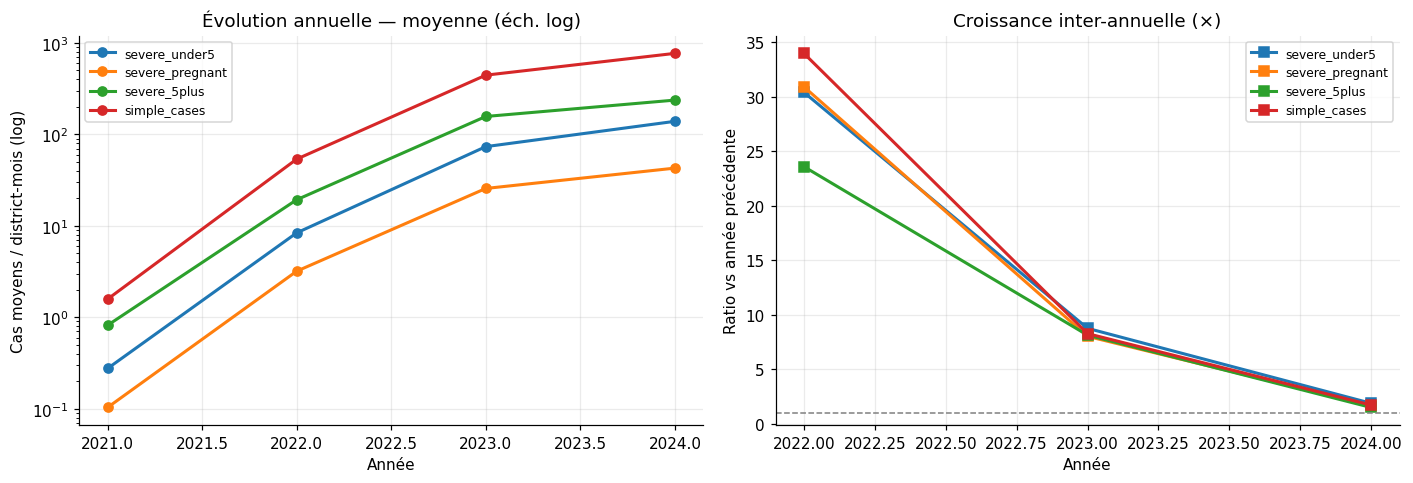

In [54]:
yearly = df.groupby('annee')[TARGETS].agg(['mean','median'])
yearly.columns = ['_'.join(c) for c in yearly.columns]
print(df.groupby('annee')[TARGETS].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Moyennes par année (log scale)
ax = axes[0]
for t, lbl in zip(TARGETS, TARGETS_LABELS):
    ax.plot(df.groupby('annee')[t].mean().index,
            df.groupby('annee')[t].mean().values, marker='o', label=t, linewidth=2)
ax.set_yscale('log'); ax.set_xlabel('Année')
ax.set_ylabel('Cas moyens / district-mois (log)')
ax.set_title('Évolution annuelle — moyenne (éch. log)')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Ratio de croissance année sur année
ax2 = axes[1]
for t, lbl in zip(TARGETS, TARGETS_LABELS):
    vals = df.groupby('annee')[t].mean()
    ratio = vals / vals.shift(1)
    ax2.plot(vals.index[1:], ratio.dropna().values, marker='s', label=t, linewidth=2)
ax2.axhline(1, color='grey', linestyle='--', linewidth=1)
ax2.set_xlabel('Année'); ax2.set_ylabel('Ratio vs année précédente')
ax2.set_title('Croissance inter-annuelle (×)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

plt.tight_layout(); plt.show()

**Non-stationnarité d'ampleur épidémiologiquement suspecte.** Les cas moyens par district-mois sont multipliés par **~500** entre 2021 et 2024 pour les cas graves chez les enfants. Ce type de croissance exponentielle en 4 ans est incompatible avec la dynamique réelle du paludisme endémique au Cameroun. L'explication la plus plausible est une **montée en charge progressive du système de surveillance DHIS2** (couverture des districts, numérisation, formation des agents de saisie) — phénomène documenté dans toute l'Afrique subsaharienne au début des années 2020.

**Conséquence directe pour la modélisation :**
- Un split chronologique strict (train ≤ 2023 / test = 2024) force une **extrapolation hors de la plage d'entraînement** — test de robustesse légitime mais représentant le pire cas.
- Un split stratifié par année (retenu comme split principal) donne une évaluation plus représentative de l'usage visé.
- Cette limite sera chiffrée explicitement en section 11.

### 4.3 Saisonnalité et dynamique climatique

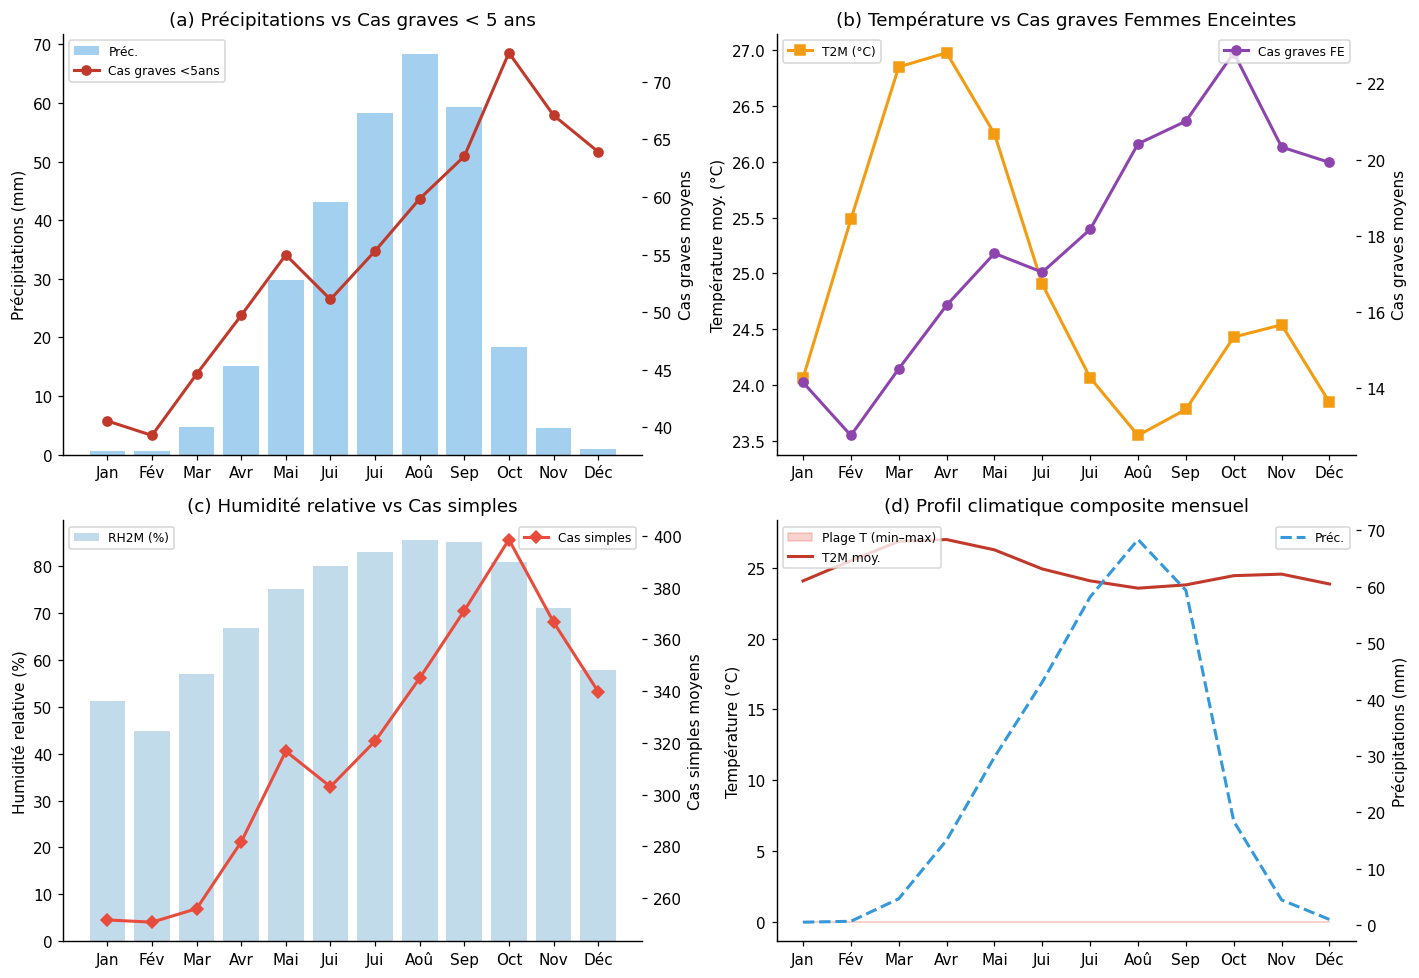

In [55]:
MONTH_ORDER = ['Janvier','Février','Mars','Avril','Mai','Juin',
               'Juillet','Août','Septembre','Octobre','Novembre','Décembre']
seasonal = df.groupby('mois')[['prectotcorr','t2m','rh2m'] + TARGETS].mean().reindex(MONTH_ORDER)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Précipitations vs cas graves sous-5
ax1 = axes[0,0]; ax1b = ax1.twinx()
ax1.bar(range(12), seasonal['prectotcorr'], color='#85c1e9', alpha=0.75, label='Préc. (mm)')
ax1b.plot(range(12), seasonal['severe_under5'], color='#c0392b', marker='o', lw=2, label='Cas graves < 5ans')
ax1.set_xticks(range(12)); ax1.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax1.set_ylabel('Précipitations (mm)'); ax1b.set_ylabel('Cas graves moyens')
ax1.set_title('(a) Précipitations vs Cas graves < 5 ans')
lines1, _ = ax1.get_legend_handles_labels(); lines2, _ = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, ['Préc.','Cas graves <5ans'], loc='upper left', fontsize=8)

# (b) Température vs cas femmes enceintes
ax2 = axes[0,1]; ax2b = ax2.twinx()
ax2.plot(range(12), seasonal['t2m'], color='#f39c12', marker='s', lw=2, label='T2M (°C)')
ax2b.plot(range(12), seasonal['severe_pregnant'], color='#8e44ad', marker='o', lw=2, label='Cas graves FE')
ax2.set_xticks(range(12)); ax2.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax2.set_ylabel('Température moy. (°C)'); ax2b.set_ylabel('Cas graves moyens')
ax2.set_title('(b) Température vs Cas graves Femmes Enceintes')
ax2.legend(loc='upper left', fontsize=8); ax2b.legend(loc='upper right', fontsize=8)

# (c) Humidité relative vs cas simples
ax3 = axes[1,0]; ax3b = ax3.twinx()
ax3.bar(range(12), seasonal['rh2m'], color='#a9cce3', alpha=0.7, label='RH2M (%)')
ax3b.plot(range(12), seasonal['simple_cases'], color='#e74c3c', marker='D', lw=2, label='Cas simples')
ax3.set_xticks(range(12)); ax3.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax3.set_ylabel('Humidité relative (%)'); ax3b.set_ylabel('Cas simples moyens')
ax3.set_title('(c) Humidité relative vs Cas simples')
ax3.legend(loc='upper left', fontsize=8); ax3b.legend(loc='upper right', fontsize=8)

# (d) Profil climatique composite
ax4 = axes[1,1]
ax4.fill_between(range(12), seasonal['t2m_min'] if 't2m_min' in seasonal else 0,
                  seasonal['t2m_max'] if 't2m_max' in seasonal else 0,
                  alpha=0.25, color='#e74c3c', label='Plage T (min–max)')
ax4.plot(range(12), seasonal['t2m'], color='#c0392b', lw=2, label='T2M moy.')
ax4_b = ax4.twinx()
ax4_b.plot(range(12), seasonal['prectotcorr'], color='#3498db', lw=2, linestyle='--', label='Préc.')
ax4.set_xticks(range(12)); ax4.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax4.set_ylabel('Température (°C)'); ax4_b.set_ylabel('Précipitations (mm)')
ax4.set_title('(d) Profil climatique composite mensuel')
ax4.legend(loc='upper left', fontsize=8); ax4_b.legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

**Nous constatons un signal saisonnier cohérent avec la biologie du vecteur.** Les cas graves augmentent dès le début de la saison des pluies (mars–avril) et restent élevés jusqu'en septembre, avec un léger décalage par rapport au pic de précipitation lui-même. Ce décalage justifie *a posteriori* l'usage des variables climatiques retardées (`_lag1`, `_lag2`) construites en section 4.4.


### 4.4 Hétérogénéité régionale et ZAE

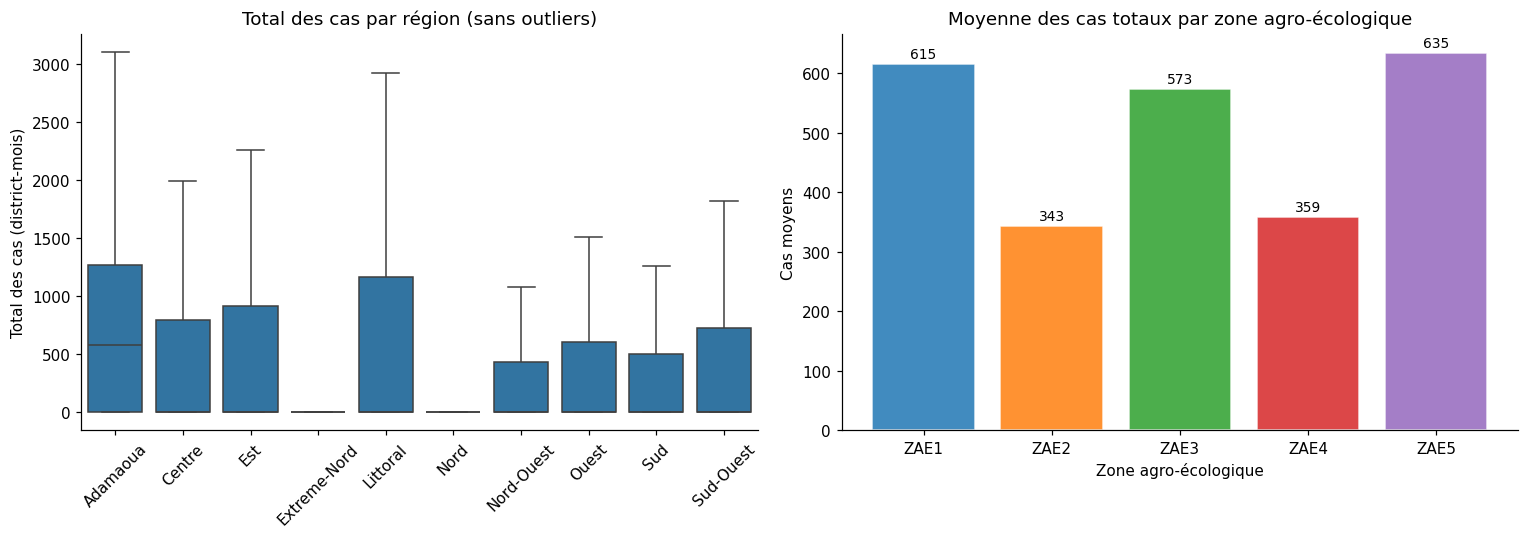

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------
# 1. Box-plot par région (Corrigé avec Seaborn)
# --------------------------------------------
ax = axes[0]
# Calcul de l'ordre en fonction de la médiane
order_reg = df.groupby('region')['total_cases'].median().sort_values(ascending=False).index

# Utilisation de seaborn pour avoir le paramètre order
sns.boxplot(data=df, x='region', y='total_cases', ax=ax, 
            order=order_reg, showfliers=False)

ax.set_title('Total des cas par région (sans outliers)')
ax.set_xlabel('')
ax.set_ylabel('Total des cas (district-mois)')
ax.tick_params(axis='x', rotation=45) # Inclinaison des labels

# --------------------------------------------
# 2. Cas par ZAE (Inchangé)
# --------------------------------------------
ax2 = axes[1]
zae_means = {}
for z in range(1, 6):
    zae_means[f'ZAE{z}'] = df.loc[df[f'zae{z}']==1, 'total_cases'].mean()
    
bars = ax2.bar(zae_means.keys(), zae_means.values(),
               color=[f'C{i}' for i in range(5)], alpha=0.85, edgecolor='white')

ax2.set_title('Moyenne des cas totaux par zone agro-écologique')
ax2.set_xlabel('Zone agro-écologique')
ax2.set_ylabel('Cas moyens')

for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Constat sur la forte hétérogénéité régionale.** Les régions Extrême-Nord, Centre et Littoral présentent les distributions les plus dispersées et les valeurs maximales les plus élevées  cohérent avec leur poids démographique (Centre/Littoral abritent les grandes métropoles) et, pour l'Extrême-Nord, des conditions climatiques et un accès aux soins différents. Ceci confirme l'intérêt d'inclure la région/le district comme variables explicatives à part entière.

### 4.5 Matrice de corrélation — climat, interventions & cibles

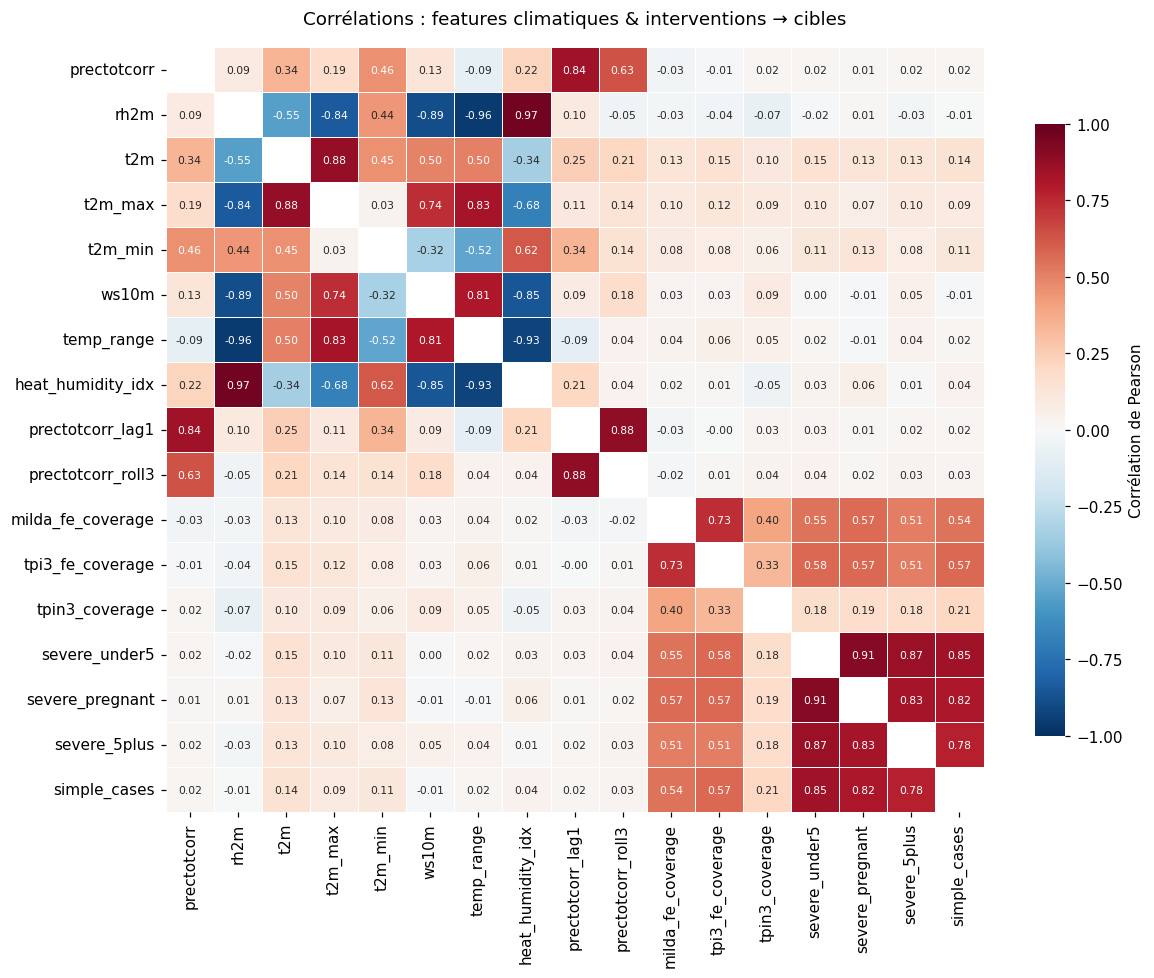

In [57]:
corr_cols = ['prectotcorr','rh2m','t2m','t2m_max','t2m_min','ws10m','temp_range',
             'heat_humidity_idx','prectotcorr_lag1','prectotcorr_roll3',
             'milda_fe_coverage','tpi3_fe_coverage','tpin3_coverage',
             'severe_under5','severe_pregnant','severe_5plus','simple_cases']
corr = df[corr_cols].corr()

mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})
ax.set_title('Corrélations : features climatiques & interventions → cibles', pad=15)
plt.tight_layout(); plt.show()

### 4.6 Corrélations inter-cibles (argument pour la prédiction multi-sortie)

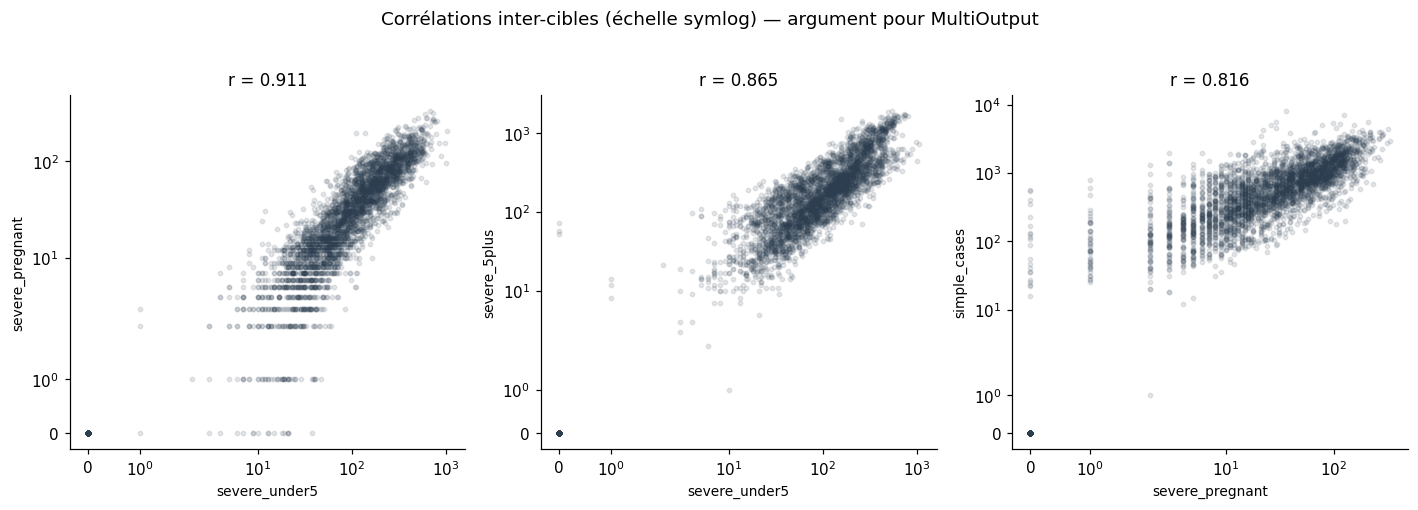

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
pairs = [('severe_under5','severe_pregnant'),
         ('severe_under5','severe_5plus'),
         ('severe_pregnant','simple_cases')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.12, s=8, color='#2c3e50')
    r = df[[x,y]].corr().iloc[0,1]
    ax.set_xlabel(x, fontsize=9); ax.set_ylabel(y, fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=11)
    ax.set_xscale('symlog'); ax.set_yscale('symlog')
fig.suptitle("Corrélations inter-cibles (échelle symlog) — argument pour MultiOutput", y=1.02)
plt.tight_layout(); plt.show()

**corrélations linéaires climat -> cas faibles, corrélations entre cibles très fortes.** Aucune variable climatique n'atteint une corrélation linéaire de Pearson supérieure à 0,15 avec les cibles : le lien climat/paludisme existe (cf. saisonnalité ci-dessus) mais il est **non-linéaire et probablement médié par d'autres facteurs** (population, interventions), ce qui justifie le recours à des modèles non-linéaires (forêts, boosting) plutôt qu'à une simple régression linéaire. En revanche, les quatre cibles sont **fortement corrélées entre elles (0,78 à 0,91)**, un district/mois à forte charge de cas graves chez les enfants l'est aussi pour les femmes enceintes et la population générale. Cette corrélation inter-cibles est l'argument principal en faveur d'une **prédiction multi-cible** (section 8) : un modèle multi-sortie peut exploiter ce signal partagé.

<a id="5"></a>
## 5. Préparation de la modélisation — Variables, Cibles, Anti-fuite

### 5.1 Correspondance population ↔ cible

| Population | Cibles disponibles |
|---|---|
| Femmes enceintes | `severe_pregnant` (cas graves) |
| Enfants < 5 ans | `severe_under5` (cas graves) |
| Population générale | `severe_5plus` (cas graves) + `simple_cases` (global) |

> **Limite documentée :** `simple_cases` n'est **pas désagrégé par population** dans les données sources. Un seul modèle global est donc entraîné, en précisant cette contrainte plutôt qu'en la masquant.

### 5.2 Définition des jeux de variables par cible

In [59]:
# ── Variables communes à toutes les cibles ────────────────────────────────
region_cols = [c for c in df.columns if c.startswith('reg_')]
zae_cols    = [f'zae{i}' for i in range(1, 6)]

COMMON_FEATURES = [
    'prectotcorr','rh2m','t2m','t2m_max','t2m_min','wd10m','ws10m',
    'temp_range','temp_range_lag1','heat_humidity_idx',
    'prectotcorr_lag1','prectotcorr_lag2',
    't2m_lag1','t2m_lag2','t2m_max_lag1','t2m_max_lag2',
    't2m_min_lag1','t2m_min_lag2',
    'rh2m_lag1','rh2m_lag2',
    'prectotcorr_roll3','prectotcorr_roll6',
    'month_num','month_sin','month_cos','annee','district_encoded',
] + zae_cols + region_cols

PREGNANT_FEATURES = [
    'pregnant_women','tpi1_fe_doses','tpi3_fe_doses','milda_fe',
    'milda_fe_lag1','milda_fe_lag2',
    'tpi1_fe_coverage','tpi3_fe_coverage','milda_fe_coverage','tpi_fe_total',
]

UNDER5_FEATURES = [
    'surviving_infants','m12_23','under_2_population',
    'tpin1_doses','tpin2_doses','tpin3_doses','milda_nourrissons',
    'milda_nourrissons_lag1','milda_nourrissons_lag2',
    'tpin1_coverage','tpin2_coverage','tpin3_coverage',
    'milda_nourrissons_coverage','tpin_total',
]

GENERAL_FEATURES = ['district_population','milda_total','tpi_total','pop_density_proxy']

FEATURE_SETS = {
    'severe_under5':   COMMON_FEATURES + UNDER5_FEATURES,
    'severe_pregnant': COMMON_FEATURES + PREGNANT_FEATURES,
    'severe_5plus':    COMMON_FEATURES + GENERAL_FEATURES,
    'simple_cases':    COMMON_FEATURES + GENERAL_FEATURES + ['pregnant_women','surviving_infants'],
}

# ── Vérification anti-fuite ────────────────────────────────────────────────
TARGETS = list(FEATURE_SETS.keys())
LEAKAGE_COLS = ['total_severe_cases','total_simple_cases','total_cases',
                 'severe_case_ratio','severe_threshold_alert']

print("Vérification anti-fuite de données :")
for t, feats in FEATURE_SETS.items():
    fuite = (set(feats) & set(TARGETS)) | (set(feats) & set(LEAKAGE_COLS))
    status = "✓ OK" if not fuite else f"❌ FUITE DÉTECTÉE : {fuite}"
    print(f"  {t:18s} → {len(feats):2d} features  {status}")

Vérification anti-fuite de données :
  severe_under5      → 56 features  ✓ OK
  severe_pregnant    → 52 features  ✓ OK
  severe_5plus       → 46 features  ✓ OK
  simple_cases       → 48 features  ✓ OK


<a id="6"></a>
## 6. Stratégie de validation & split

Deux contraintes structurelles guident le découpage :
1. **Non-stationnarité temporelle forte** : un split uniquement chronologique défavorise structurellement les modèles (extrapolation hors plage).
2. **Structure panel** : 198 districts répétés sur 48 mois — un `KFold` classique risque de surestimer la performance en validant sur les mêmes districts qu'à l'entraînement.

**Stratégie retenue :** split aléatoire **stratifié par année** (80/20), associé à une **validation croisée groupée par district** (`GroupKFold`, 4 plis) pour le réglage des hyperparamètres. Un test complémentaire temporel (train ≤ 2023 / test = 2024) quantifie la robustesse à la non-stationnarité (section 11).

In [60]:
# ── Split principal (80/20 stratifié par année) ────────────────────────────
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df['annee']
)
print(f"Train : {len(idx_train):,} lignes  |  Test : {len(idx_test):,} lignes")
print()
print("Répartition par année (train vs test) :")
rep = pd.DataFrame({
    'Train': df.loc[idx_train,'annee'].value_counts(normalize=True).sort_index(),
    'Test':  df.loc[idx_test,'annee'].value_counts(normalize=True).sort_index(),
}).map(lambda x: f"{x:.1%}")
print(rep)

Train : 7,603 lignes  |  Test : 1,901 lignes

Répartition par année (train vs test) :
       Train   Test
annee              
2021   25.0%  25.0%
2022   25.0%  25.0%
2023   25.0%  25.0%
2024   25.0%  25.0%


<a id="7"></a>
## 7. Transformation des cibles — log(1 + y)

Avant modélisation, on applique la transformation `log1p` sur toutes les cibles. Cette transformation est **standard pour les données de comptage épidémiologique** à forte inflation de zéros et forte asymétrie :
- Compresse les valeurs extrêmes sans supprimer d'information
- Réduit l'asymétrie de 2.8–3.5 vers ~1.0–1.5 (cf. EDA section 4.1)
- Permet à des modèles qui minimisent une perte quadratique (RMSE) de se concentrer sur la structure de la distribution plutôt que sur les quelques valeurs extrêmes
- La back-transformation est `expm1(ŷ)` — on reporte **toujours les métriques dans l'espace original** pour comparabilité.

> **Alternative non retenue ici mais mentionnée** : régression de Poisson ou binomiale négative (modèles de comptage), plus appropriées en théorie, non disponibles dans RandomForest/HistGB sans wrapper externe.

In [61]:
# Cibles transformées (colonnes supplémentaires, non écrasées pour permettre les métriques originales)
for t in TARGETS:
    df[f'{t}_log'] = np.log1p(df[t])

# Affichage comparatif de l'asymétrie
print("Asymétrie avant/après log1p :")
for t in TARGETS:
    sk_before = df[t].skew()
    sk_after  = df[f'{t}_log'].skew()
    print(f"  {t:18s} : {sk_before:+.2f} → {sk_after:+.2f}")

TARGETS_LOG = [f'{t}_log' for t in TARGETS]  # cibles à modéliser

Asymétrie avant/après log1p :
  severe_under5      : +2.83 → +0.64
  severe_pregnant    : +2.82 → +0.82
  severe_5plus       : +3.46 → +0.62
  simple_cases       : +3.05 → +0.55


<a id="8"></a>
## 8. Modélisation — Dummy → Ridge → Random Forest → HistGB → Stacking

**Architecture de comparaison :**
| Modèle | Régularisation | Rationale |
|---|---|---|
| `DummyRegressor` (moyenne) | — | Borne inférieure de référence |
| `Ridge` (linéaire, L2) + StandardScaler | Forte via `alpha` | Capture la composante linéaire ; interprétable ; rapide |
| `RandomForestRegressor` | Implicite (bagging + profondeur) | Non-linéaire ; robuste aux outliers ; OOB dispo |
| `ExtraTreesRegressor` | Plus randomisé que RF | Souvent plus rapide, variance plus faible |
| `HistGradientBoostingRegressor` | L2 explicite + `min_samples_leaf` | Équivalent LightGBM natif sklearn ; gère les NaN |
| **Stacking** (RF + HGB → Ridge) | — | Combine les prédicteurs forts, méta-apprentissage |

Chaque modèle est réglé par `RandomizedSearchCV` avec `GroupKFold(4)` groupé par district.

In [62]:
def metrics_original(y_true_log, y_pred_log):
    """Calcule MAE, RMSE, R² dans l'espace original (back-transformation expm1)."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, None))  # clips négatifs → 0
    return {
        'MAE':  round(mean_absolute_error(y_true, y_pred), 3),
        'RMSE': round(mean_squared_error(y_true, y_pred)**0.5, 3),
        'R2':   round(r2_score(y_true, y_pred), 4),
    }

def metrics_log(y_true_log, y_pred_log):
    """Métriques dans l'espace log (pour la CV)."""
    return {
        'MAE_log':  round(mean_absolute_error(y_true_log, y_pred_log), 4),
        'RMSE_log': round(mean_squared_error(y_true_log, y_pred_log)**0.5, 4),
        'R2_log':   round(r2_score(y_true_log, y_pred_log), 4),
    }

# ── Grilles d'hyperparamètres ─────────────────────────────────────────────
RIDGE_GRID = {'ridge__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]}

RF_GRID = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [None, 12, 18, 24],
    'min_samples_leaf':[1, 2, 4, 8],
    'max_features':    ['sqrt', 0.4, 0.6, 0.8],
    'max_samples':     [0.7, 0.8, None],
}

ET_GRID = {
    'n_estimators':    [200, 300],
    'max_depth':       [None, 15, 20],
    'min_samples_leaf':[1, 2, 4],
    'max_features':    ['sqrt', 0.5, 0.7],
}

HGB_GRID = {
    'max_iter':          [200, 300, 500],
    'max_depth':         [3, 5, 7, None],
    'learning_rate':     [0.02, 0.05, 0.1, 0.15],
    'l2_regularization': [0, 0.05, 0.1, 0.5, 1.0],
    'min_samples_leaf':  [10, 20, 30, 50],
    'max_leaf_nodes':    [None, 31, 63],
}

print("✓ Fonctions de métriques et grilles d'hyperparamètres définies.")

✓ Fonctions de métriques et grilles d'hyperparamètres définies.


In [63]:
results       = {}   # {target: {model_name: {metrics...}}}
best_models   = {}   # {target: {model_name: fitted_model}}
test_preds    = {}   # {target: {model_name: y_pred_original}}

t_global = time.time()

for target in TARGETS:
    target_log = f'{target}_log'
    feats      = FEATURE_SETS[target]

    X_train = df.loc[idx_train, feats]
    y_train = df.loc[idx_train, target_log]
    X_test  = df.loc[idx_test,  feats]
    y_test  = df.loc[idx_test,  target_log]

    groups_train = df.loc[idx_train, 'district']
    gkf_splits   = list(GroupKFold(n_splits=4).split(X_train, y_train, groups_train))

    results[target]     = {}
    best_models[target] = {}
    test_preds[target]  = {}

    # ── Dummy ────────────────────────────────────────────────────────────
    dummy = DummyRegressor(strategy='mean').fit(X_train, y_train)
    p_d   = dummy.predict(X_test)
    results[target]['Dummy'] = metrics_original(y_test, p_d)
    best_models[target]['Dummy'] = dummy

    # ── Ridge ────────────────────────────────────────────────────────────
    ridge_pipe   = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
    ridge_search = RandomizedSearchCV(
        ridge_pipe, RIDGE_GRID, n_iter=7, cv=gkf_splits,
        scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
    )
    ridge_search.fit(X_train, y_train)
    p_r = ridge_search.best_estimator_.predict(X_test)
    results[target]['Ridge'] = {
        **metrics_original(y_test, p_r),
        'best_params': ridge_search.best_params_,
        'cv_r2': round(ridge_search.best_score_, 4),
    }
    best_models[target]['Ridge'] = ridge_search.best_estimator_
    test_preds[target]['Ridge']  = np.expm1(np.clip(p_r, 0, None))

    # ── Random Forest ────────────────────────────────────────────────────
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, oob_score=True),
        RF_GRID, n_iter=15, cv=gkf_splits,
        scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_search.fit(X_train, y_train)
    p_rf = rf_search.best_estimator_.predict(X_test)
    results[target]['RandomForest'] = {
        **metrics_original(y_test, p_rf),
        'best_params': rf_search.best_params_,
        'cv_r2': round(rf_search.best_score_, 4),
        'oob_r2': round(rf_search.best_estimator_.oob_score_, 4),
    }
    best_models[target]['RandomForest'] = rf_search.best_estimator_
    test_preds[target]['RandomForest']  = np.expm1(np.clip(p_rf, 0, None))

    # ── Extra Trees ──────────────────────────────────────────────────────
    et_search = RandomizedSearchCV(
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        ET_GRID, n_iter=10, cv=gkf_splits,
        scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
    )
    et_search.fit(X_train, y_train)
    p_et = et_search.best_estimator_.predict(X_test)
    results[target]['ExtraTrees'] = {
        **metrics_original(y_test, p_et),
        'best_params': et_search.best_params_,
        'cv_r2': round(et_search.best_score_, 4),
    }
    best_models[target]['ExtraTrees'] = et_search.best_estimator_
    test_preds[target]['ExtraTrees']  = np.expm1(np.clip(p_et, 0, None))

    # ── HistGradientBoosting ─────────────────────────────────────────────
    hgb_search = RandomizedSearchCV(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        HGB_GRID, n_iter=20, cv=gkf_splits,
        scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
    )
    hgb_search.fit(X_train, y_train)
    p_hgb = hgb_search.best_estimator_.predict(X_test)
    results[target]['HistGB'] = {
        **metrics_original(y_test, p_hgb),
        'best_params': hgb_search.best_params_,
        'cv_r2': round(hgb_search.best_score_, 4),
    }
    best_models[target]['HistGB'] = hgb_search.best_estimator_
    test_preds[target]['HistGB']  = np.expm1(np.clip(p_hgb, 0, None))

    # ── Stacking (RF + HGB → Ridge méta) ────────────────────────────────
    stacking = StackingRegressor(
        estimators=[
            ('rf',  RandomForestRegressor(**{k:v for k,v in rf_search.best_params_.items()},
                                           random_state=RANDOM_STATE, n_jobs=-1)),
            ('hgb', HistGradientBoostingRegressor(**{k:v for k,v in hgb_search.best_params_.items()},
                                                   random_state=RANDOM_STATE)),
        ],
        final_estimator=Ridge(alpha=10),
        cv=4, n_jobs=-1
    )
    stacking.fit(X_train, y_train)
    p_stk = stacking.predict(X_test)
    results[target]['Stacking'] = {
        **metrics_original(y_test, p_stk),
        'cv_r2': '-',
    }
    best_models[target]['Stacking'] = stacking
    test_preds[target]['Stacking']  = np.expm1(np.clip(p_stk, 0, None))

    elapsed = round(time.time() - t_global, 1)
    print(f"[{elapsed:>6}s] ✓ {target} — RF R²={results[target]['RandomForest']['R2']:.3f}  "
          f"HGB R²={results[target]['HistGB']['R2']:.3f}  "
          f"Stack R²={results[target]['Stacking']['R2']:.3f}")

print(f"\n✅ Entraînement complet — {round(time.time()-t_global,1)}s total.")

[ 505.4s] ✓ severe_under5 — RF R²=0.808  HGB R²=0.836  Stack R²=0.837
[1155.0s] ✓ severe_pregnant — RF R²=0.871  HGB R²=0.875  Stack R²=0.881
[1477.8s] ✓ severe_5plus — RF R²=0.914  HGB R²=0.923  Stack R²=0.927
[1807.1s] ✓ simple_cases — RF R²=0.824  HGB R²=0.840  Stack R²=0.836

✅ Entraînement complet — 1807.1s total.


## Tableau de résultats complet

In [64]:
rows = []
for target in TARGETS:
    for model_name, m in results[target].items():
        rows.append({
            'Cible': target, 'Modèle': model_name,
            'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R²': m['R2'],
            'CV R² (train)': m.get('cv_r2', '-'),
            'OOB R²': m.get('oob_r2', '-'),
        })

results_df = (pd.DataFrame(rows)
              .sort_values(['Cible','R²'], ascending=[True, False])
              .reset_index(drop=True))
results_df

,Cible,Modèle,MAE,RMSE,R²,CV R² (train),OOB R²
0,severe_5plus,ExtraTrees,18.752,46.316,0.956,0.976,-
1,severe_5plus,Stacking,24.701,59.678,0.927,-,-
2,severe_5plus,HistGB,25.178,61.231,0.923,0.978,-
3,severe_5plus,RandomForest,25.887,64.620,0.914,0.977,0.989
4,severe_5plus,Dummy,104.543,241.166,-0.192,-,-
5,severe_5plus,Ridge,58007.131,2492693.170,-127291209.223,0.767,-
6,severe_pregnant,ExtraTrees,4.204,11.330,0.898,0.947,-
7,severe_pregnant,Stacking,4.692,12.254,0.881,-,-
8,severe_pregnant,HistGB,4.801,12.573,0.875,0.942,-
9,severe_pregnant,RandomForest,5.004,12.735,0.871,0.946,0.968


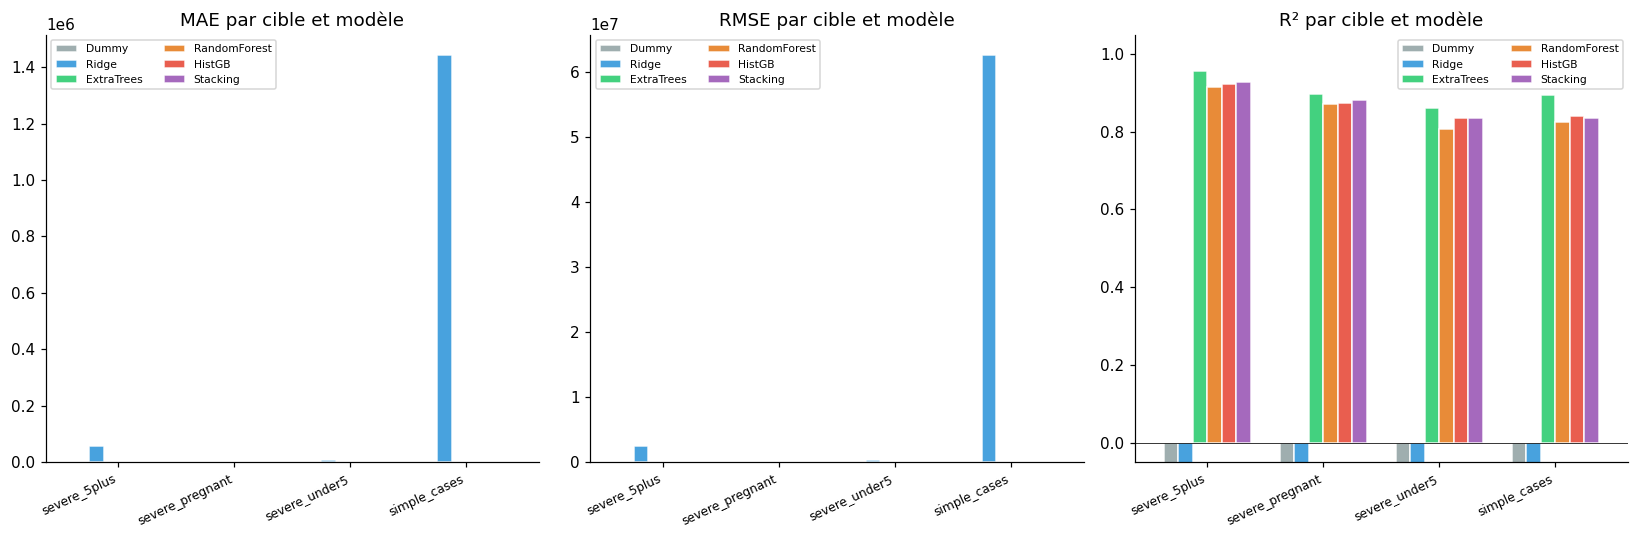

In [65]:
# ── Visualisation comparative ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_order = ['Dummy','Ridge','ExtraTrees','RandomForest','HistGB','Stacking']
colors = {'Dummy':'#95a5a6','Ridge':'#3498db','ExtraTrees':'#2ecc71',
          'RandomForest':'#e67e22','HistGB':'#e74c3c','Stacking':'#9b59b6'}

for ax, metric in zip(axes, ['MAE','RMSE','R²']):
    pivot = (results_df[results_df['Modèle'].isin(models_order)]
             .pivot(index='Cible', columns='Modèle', values=metric)
             [models_order])
    pivot.plot(kind='bar', ax=ax, color=[colors[m] for m in models_order],
               alpha=0.9, width=0.75, edgecolor='white')
    ax.set_title(f'{metric} par cible et modèle')
    ax.set_xlabel(''); ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    ax.legend(fontsize=7, ncol=2)
    if metric == 'R²':
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

<a id="9"></a>
## 9. Prédiction Multi-Cible

Les corrélations inter-cibles de 0.78–0.91 (section 4.6) justifient deux approches multi-sortie :
- **`MultiOutputRegressor`** : entraîne un modèle indépendant par cible, mais partage la structure du jeu de features unifiées.
- **`RegressorChain`** : les prédictions des cibles précédentes deviennent des features pour les cibles suivantes — exploite la dépendance séquentielle entre cibles.

In [66]:
severe_targets  = ['severe_under5','severe_pregnant','severe_5plus']
severe_logs     = [f'{t}_log' for t in severe_targets]

# Union des features pour les 3 cibles graves
multi_feats = sorted(set(FEATURE_SETS['severe_under5'])
                     | set(FEATURE_SETS['severe_pregnant'])
                     | set(FEATURE_SETS['severe_5plus']))
print(f"Features unifiées (union) : {len(multi_feats)}")

X_train_m = df.loc[idx_train, multi_feats]
Y_train_m = df.loc[idx_train, severe_logs]
X_test_m  = df.loc[idx_test,  multi_feats]
Y_test_m  = df.loc[idx_test,  severe_logs]

# ── Meilleurs hyperparamètres RF de severe_under5 comme base ──────────────
best_rf_params = {k:v for k,v in results['severe_under5']['RandomForest']['best_params'].items()}

# ── MultiOutputRegressor ──────────────────────────────────────────────────
t0 = time.time()
mo_rf = MultiOutputRegressor(
    RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1),
    n_jobs=-1
)
mo_rf.fit(X_train_m, Y_train_m)
pred_mo = mo_rf.predict(X_test_m)
print(f"MultiOutput RF : {round(time.time()-t0,1)}s")

# ── RegressorChain ─────────────────────────────────────────────────────────
t0 = time.time()
chain_rf = RegressorChain(
    RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1),
    order=[0, 1, 2], random_state=RANDOM_STATE
)
chain_rf.fit(X_train_m, Y_train_m)
pred_chain = chain_rf.predict(X_test_m)
print(f"RegressorChain RF : {round(time.time()-t0,1)}s")

# ── Comparaison ───────────────────────────────────────────────────────────
multi_rows = []
for i, t in enumerate(severe_targets):
    y_true = df.loc[idx_test, t]
    r2_mono   = results[t]['RandomForest']['R2']
    r2_mo     = r2_score(y_true, np.expm1(np.clip(pred_mo[:,i], 0, None)))
    r2_chain  = r2_score(y_true, np.expm1(np.clip(pred_chain[:,i], 0, None)))
    multi_rows.append({'Cible': t,
                        'R² Mono-cible RF': r2_mono,
                        'R² MultiOutput RF': round(r2_mo,4),
                        'R² RegressorChain': round(r2_chain,4),
                        'Gain MultiOutput': round(r2_mo - r2_mono, 4),
                        'Gain Chain':       round(r2_chain - r2_mono, 4)})

multi_df = pd.DataFrame(multi_rows)
print("\n", multi_df.to_string(index=False))

Features unifiées (union) : 70
MultiOutput RF : 14.7s
RegressorChain RF : 15.5s

           Cible  R² Mono-cible RF  R² MultiOutput RF  R² RegressorChain  Gain MultiOutput  Gain Chain
  severe_under5             0.808              0.856              0.856             0.048       0.048
severe_pregnant             0.871              0.887              0.893             0.016       0.022
   severe_5plus             0.914              0.930              0.929             0.015       0.015


<a id="10"></a>
## 10. Stabilité des modèles — variance inter-plis

On examine maintenant la distribution du R² à travers les 4 plis de validation croisée groupée par district pour les deux meilleurs modèles (RF et HistGB). Un faible écart-type = performance peu sensible au sous-ensemble de districts sélectionné = **meilleure robustesse pour un déploiement sur de nouveaux districts**.

In [67]:
stability_rows = []
for target in TARGETS:
    feats      = FEATURE_SETS[target]
    target_log = f'{target}_log'
    X_train    = df.loc[idx_train, feats]
    y_train    = df.loc[idx_train, target_log]
    groups     = df.loc[idx_train, 'district']
    gkf_splits = list(GroupKFold(n_splits=4).split(X_train, y_train, groups))

    for model_name in ['RandomForest', 'HistGB']:
        model = best_models[target][model_name]
        fold_r2 = []
        for tr_idx, val_idx in gkf_splits:
            model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            p = model.predict(X_train.iloc[val_idx])
            fold_r2.append(r2_score(y_train.iloc[val_idx], p))
        stability_rows.append({
            'Cible': target, 'Modèle': model_name,
            'R² pli 1': round(fold_r2[0],3), 'R² pli 2': round(fold_r2[1],3),
            'R² pli 3': round(fold_r2[2],3), 'R² pli 4': round(fold_r2[3],3),
            'Moyenne': round(np.mean(fold_r2),3),
            'Écart-type': round(np.std(fold_r2),4),
        })

stab_df = pd.DataFrame(stability_rows)
print(stab_df.to_string(index=False))

          Cible       Modèle  R² pli 1  R² pli 2  R² pli 3  R² pli 4  Moyenne  Écart-type
  severe_under5 RandomForest     0.974     0.975     0.959     0.966    0.969       0.007
  severe_under5       HistGB     0.974     0.974     0.959     0.968    0.969       0.006
severe_pregnant RandomForest     0.952     0.956     0.931     0.945    0.946       0.010
severe_pregnant       HistGB     0.943     0.954     0.923     0.948    0.942       0.012
   severe_5plus RandomForest     0.979     0.984     0.968     0.978    0.977       0.006
   severe_5plus       HistGB     0.978     0.982     0.970     0.981    0.978       0.004
   simple_cases RandomForest     0.984     0.983     0.979     0.983    0.982       0.002
   simple_cases       HistGB     0.986     0.981     0.978     0.984    0.982       0.003


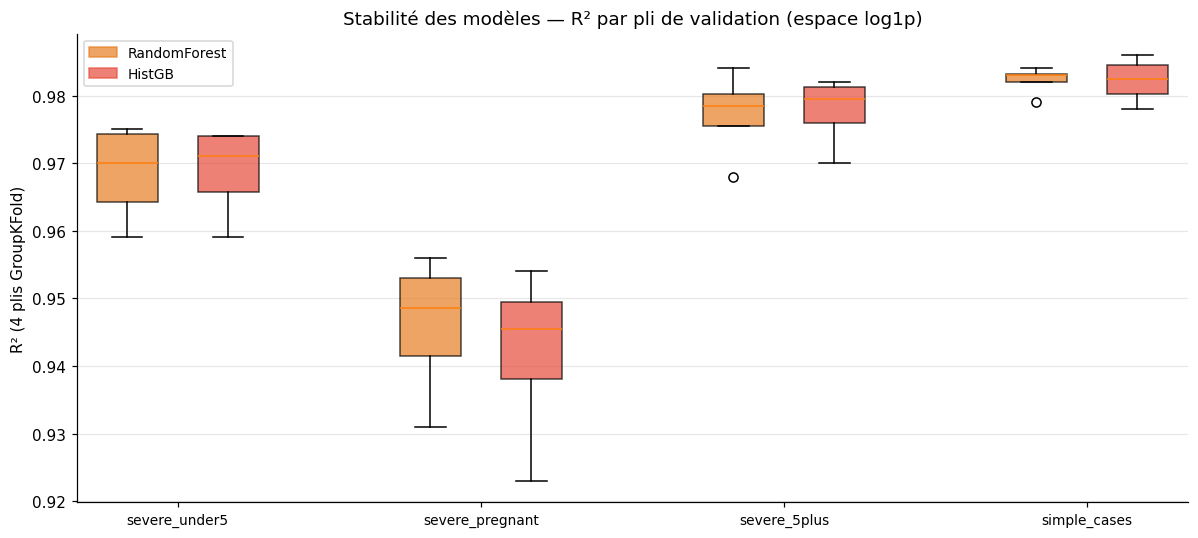

In [68]:
# ── Visualisation boxplot de stabilité ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
positions_rf  = [1, 4, 7, 10]
positions_hgb = [2, 5, 8, 11]
fold_cols = ['R² pli 1','R² pli 2','R² pli 3','R² pli 4']

for i, target in enumerate(TARGETS):
    rf_vals  = stab_df[(stab_df['Cible']==target) & (stab_df['Modèle']=='RandomForest')][fold_cols].values[0]
    hgb_vals = stab_df[(stab_df['Cible']==target) & (stab_df['Modèle']=='HistGB')][fold_cols].values[0]
    ax.boxplot([rf_vals],  positions=[positions_rf[i]],  widths=0.6,
                patch_artist=True, boxprops=dict(facecolor='#e67e22', alpha=0.7))
    ax.boxplot([hgb_vals], positions=[positions_hgb[i]], widths=0.6,
                patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.7))

import matplotlib.patches as mpatches
ax.set_xticks([1.5, 4.5, 7.5, 10.5])
ax.set_xticklabels(TARGETS, fontsize=9)
ax.set_ylabel('R² (4 plis GroupKFold)')
ax.set_title('Stabilité des modèles — R² par pli de validation (espace log1p)')
ax.legend(handles=[mpatches.Patch(color='#e67e22',alpha=0.7,label='RandomForest'),
                    mpatches.Patch(color='#e74c3c',alpha=0.7,label='HistGB')], fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

<a id="11"></a>
## 11. Robustesse temporelle — Généralisation vers 2024

On entraîne les deux meilleurs modèles (RF et HGB) sur **2021–2023** et on évalue sur **2024**. Ce test mesure la capacité du modèle à prédire une année non vue, scenario le plus réaliste pour un usage en santé publique.

In [69]:
train_temp = df['annee'] <= 2023
test_temp  = df['annee'] == 2024

temporal_rows = []
for target in TARGETS:
    feats      = FEATURE_SETS[target]
    target_log = f'{target}_log'

    for model_name in ['Ridge','RandomForest','HistGB']:
        model = best_models[target][model_name]
        model.fit(df.loc[train_temp, feats], df.loc[train_temp, target_log])
        p_log = model.predict(df.loc[test_temp, feats])
        p_orig = np.expm1(np.clip(p_log, 0, None))
        y_true = df.loc[test_temp, target]
        temporal_rows.append({
            'Cible': target, 'Modèle': model_name,
            'R² (split aleatoire)': results[target][model_name]['R2'],
            'R² (test 2024)': round(r2_score(y_true, p_orig), 4),
            'MAE (test 2024)': round(mean_absolute_error(y_true, p_orig), 2),
            'Moyenne réelle': round(y_true.mean(), 2),
            'Moyenne prédite': round(p_orig.mean(), 2),
        })

temporal_df = pd.DataFrame(temporal_rows)
print(temporal_df.to_string(index=False))

          Cible       Modèle  R² (split aleatoire)                                                               R² (test 2024)                          MAE (test 2024)  Moyenne réelle                          Moyenne prédite
  severe_under5        Ridge          -5393889.958 -24983029372113292444844504824056186687857314042301641571159095717658624.000 451409740490873845470886166590914560.000         138.780 451409740490873845470886166590914560.000
  severe_under5 RandomForest                 0.808                                                                       -0.313                                   97.070         138.780                                   57.430
  severe_under5       HistGB                 0.836                                                                       -0.273                                   94.470         138.780                                   65.310
severe_pregnant        Ridge                -1.553                                              

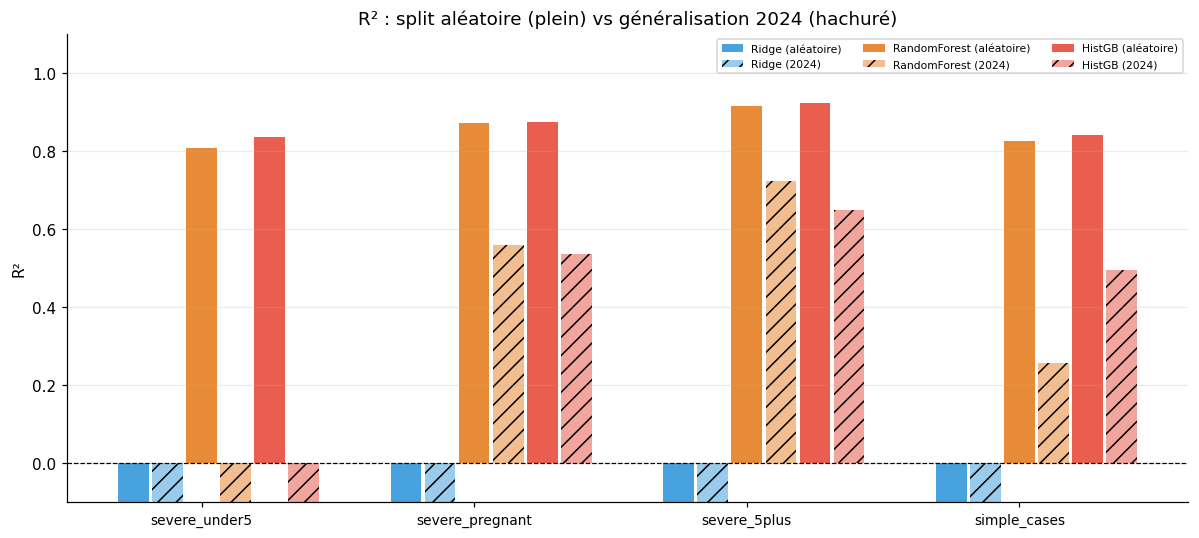

In [70]:
# Visualisation : dégradation du R² aléatoire → temporel
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TARGETS))
width = 0.25

for j, model_name in enumerate(['Ridge','RandomForest','HistGB']):
    sub = temporal_df[temporal_df['Modèle']==model_name]
    r2_rand = sub['R² (split aleatoire)'].values
    r2_temp = sub['R² (test 2024)'].values
    bars = ax.bar(x + j*width, r2_rand, width=width*0.45, alpha=0.9,
                   color=colors.get(model_name,'grey'), label=f'{model_name} (aléatoire)')
    ax.bar(x + j*width + width*0.5, r2_temp, width=width*0.45, alpha=0.5,
            color=colors.get(model_name,'grey'), hatch='//', label=f'{model_name} (2024)')

ax.set_xticks(x + width); ax.set_xticklabels(TARGETS, fontsize=9)
ax.set_ylabel('R²'); ax.set_ylim(-0.1, 1.1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("R² : split aléatoire (plein) vs généralisation 2024 (hachuré)")
ax.legend(fontsize=7, ncol=3); ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); plt.show()

<a id="12"></a>
## 12. Analyse fine des erreurs

Ainsi, nous décomposons les erreurs du meilleur modèle (Random Forest, split aléatoire) selon trois axes : **valeur prédite vs réelle**, **erreur par région**, et **erreur par mois** (saisonnalité résiduelle). Cette analyse révèle les faiblesses structurelles du modèle non visibles dans les métriques globales.

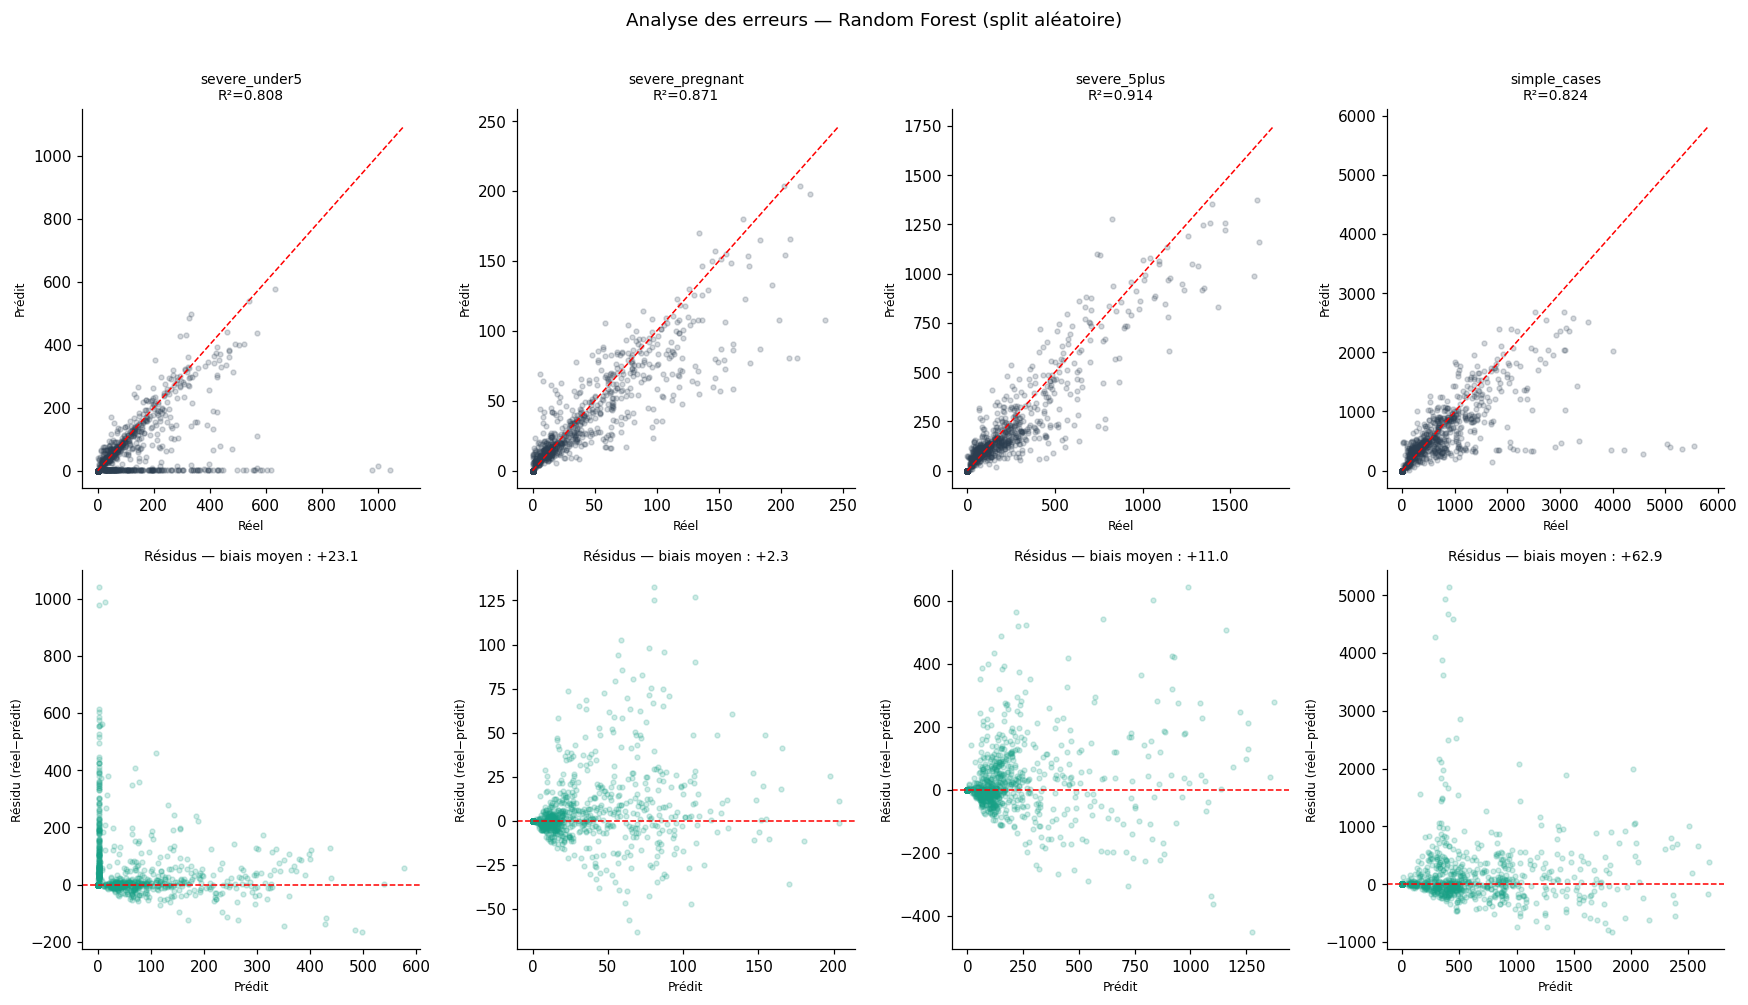

In [71]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for col, target in enumerate(TARGETS):
    model   = best_models[target]['RandomForest']
    X_test  = df.loc[idx_test, FEATURE_SETS[target]]
    y_true  = df.loc[idx_test, target]
    y_pred  = np.expm1(np.clip(model.predict(X_test), 0, None))
    resid   = y_true.values - y_pred

    # ── Scatter réel vs prédit ────────────────────────────────────────────
    ax = axes[0, col]
    ax.scatter(y_true, y_pred, alpha=0.2, s=10, color='#2c3e50')
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Parfait')
    ax.set_xlabel('Réel', fontsize=8); ax.set_ylabel('Prédit', fontsize=8)
    r2_val = results[target]['RandomForest']['R2']
    ax.set_title(f'{target}\nR²={r2_val:.3f}', fontsize=9)

    # ── Résidus vs prédits ────────────────────────────────────────────────
    ax2 = axes[1, col]
    ax2.scatter(y_pred, resid, alpha=0.2, s=10, color='#16a085')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Prédit', fontsize=8); ax2.set_ylabel('Résidu (réel−prédit)', fontsize=8)
    ax2.set_title(f'Résidus — biais moyen : {resid.mean():+.1f}', fontsize=9)

plt.suptitle("Analyse des erreurs — Random Forest (split aléatoire)", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

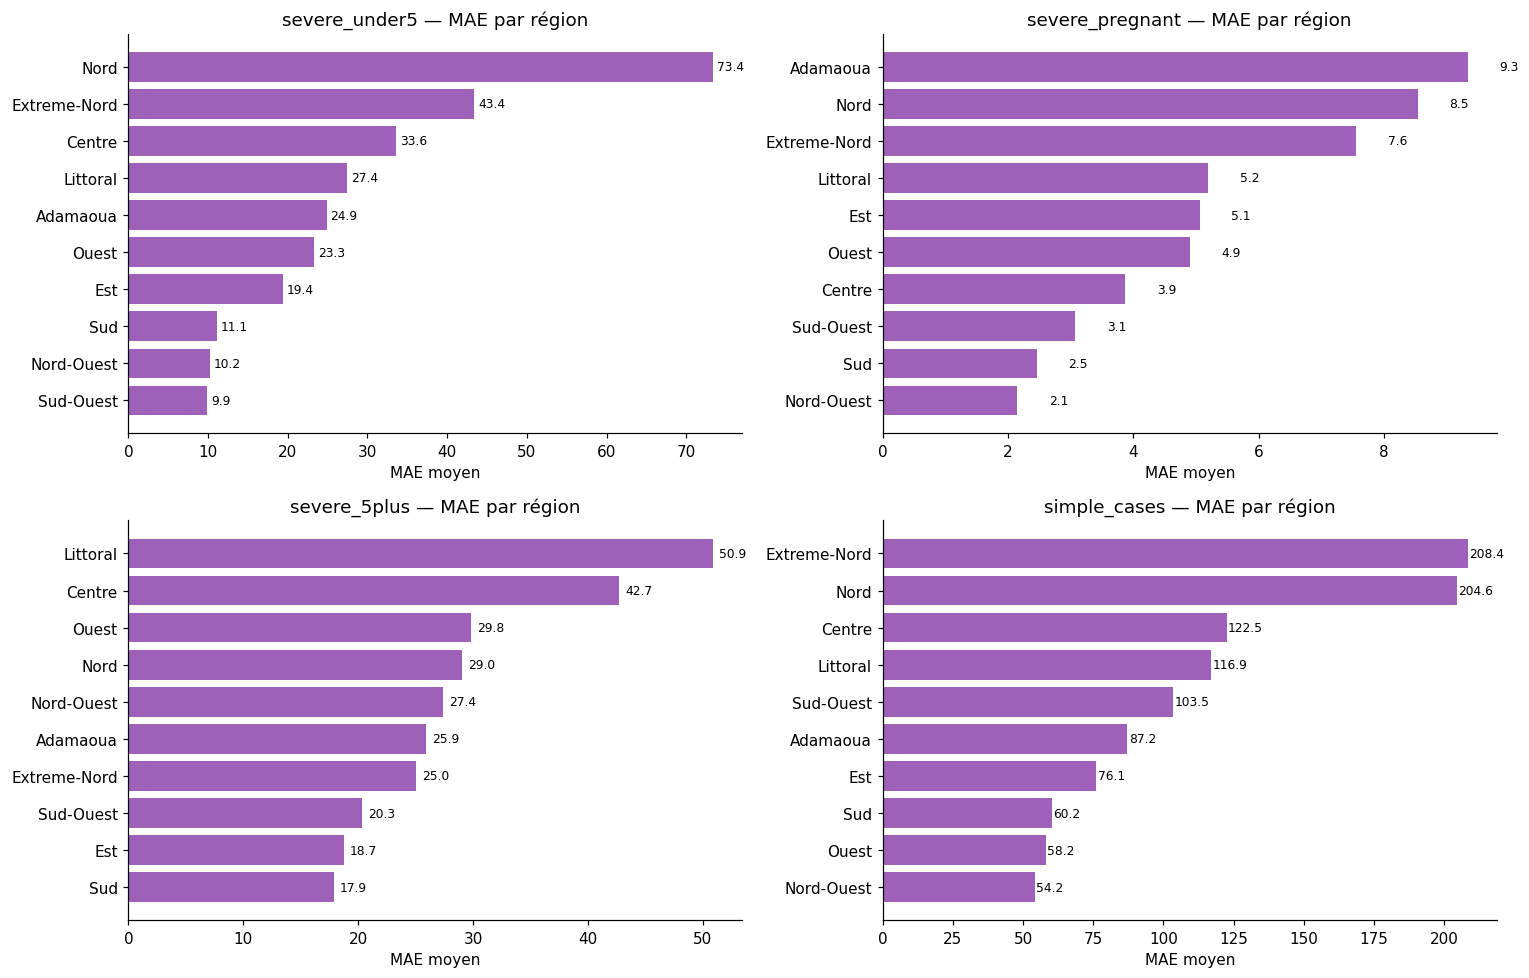

In [72]:
# ── Erreur par région ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, target in zip(axes.ravel(), TARGETS):
    model  = best_models[target]['RandomForest']
    X_test = df.loc[idx_test, FEATURE_SETS[target]]
    y_true = df.loc[idx_test, target]
    y_pred = np.expm1(np.clip(model.predict(X_test), 0, None))
    mae_by_region = (pd.DataFrame({'region': df.loc[idx_test,'region'].values,
                                    'abs_err': np.abs(y_true.values - y_pred)})
                     .groupby('region')['abs_err'].mean()
                     .sort_values(ascending=True))
    ax.barh(mae_by_region.index, mae_by_region.values, color='#8e44ad', alpha=0.85)
    ax.set_xlabel('MAE moyen'); ax.set_title(f'{target} — MAE par région')
    for i, v in enumerate(mae_by_region.values):
        ax.text(v+0.5, i, f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

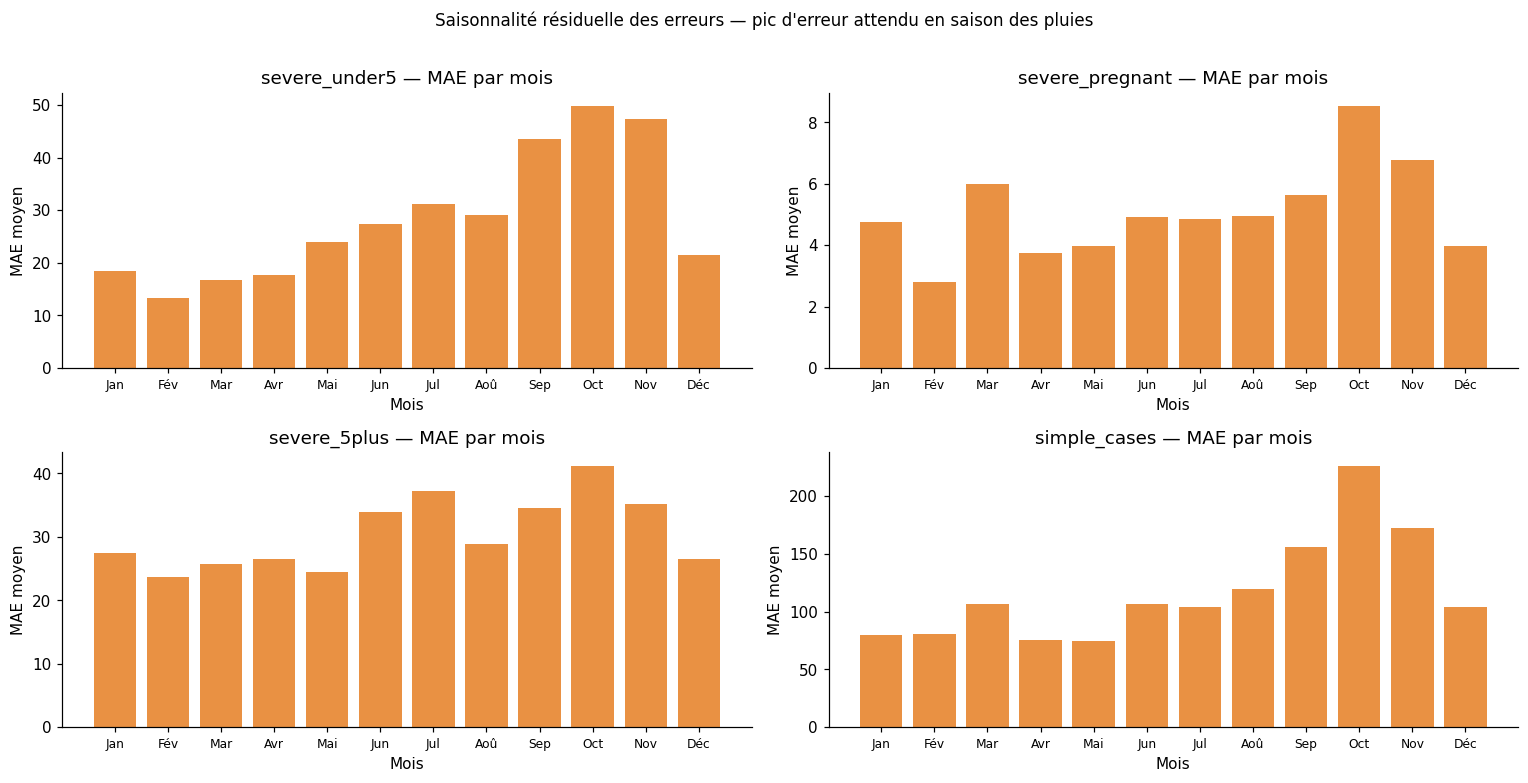

In [73]:
# ── Erreur par mois (saisonnalité résiduelle) ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

for ax, target in zip(axes.ravel(), TARGETS):
    model  = best_models[target]['RandomForest']
    X_test = df.loc[idx_test, FEATURE_SETS[target]]
    y_true = df.loc[idx_test, target]
    y_pred = np.expm1(np.clip(model.predict(X_test), 0, None))
    test_months = df.loc[idx_test, 'month_num'].values
    mae_by_month = pd.Series({m: np.mean(np.abs(y_true.values[test_months==m]
                                                  - y_pred[test_months==m]))
                               for m in range(1,13)})
    ax.bar(range(1,13), mae_by_month.values, color='#e67e22', alpha=0.85)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_xlabel('Mois'); ax.set_ylabel('MAE moyen')
    ax.set_title(f'{target} — MAE par mois')

plt.suptitle("Saisonnalité résiduelle des erreurs — pic d'erreur attendu en saison des pluies",
              fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

<a id="13"></a>
## 13. Importance des variables & Interprétation par catégorie

**Deux méthodes complémentaires** sont utilisées :
1. **MDI (Mean Decrease in Impurity)** — natif à la forêt, rapide mais biaisé vers les variables à haute cardinalité.
2. **Permutation Importance** — model-agnostique, plus fiable, plus coûteux (calculé sur le test set).

On compare les deux pour identifier les variables réellement informatives.

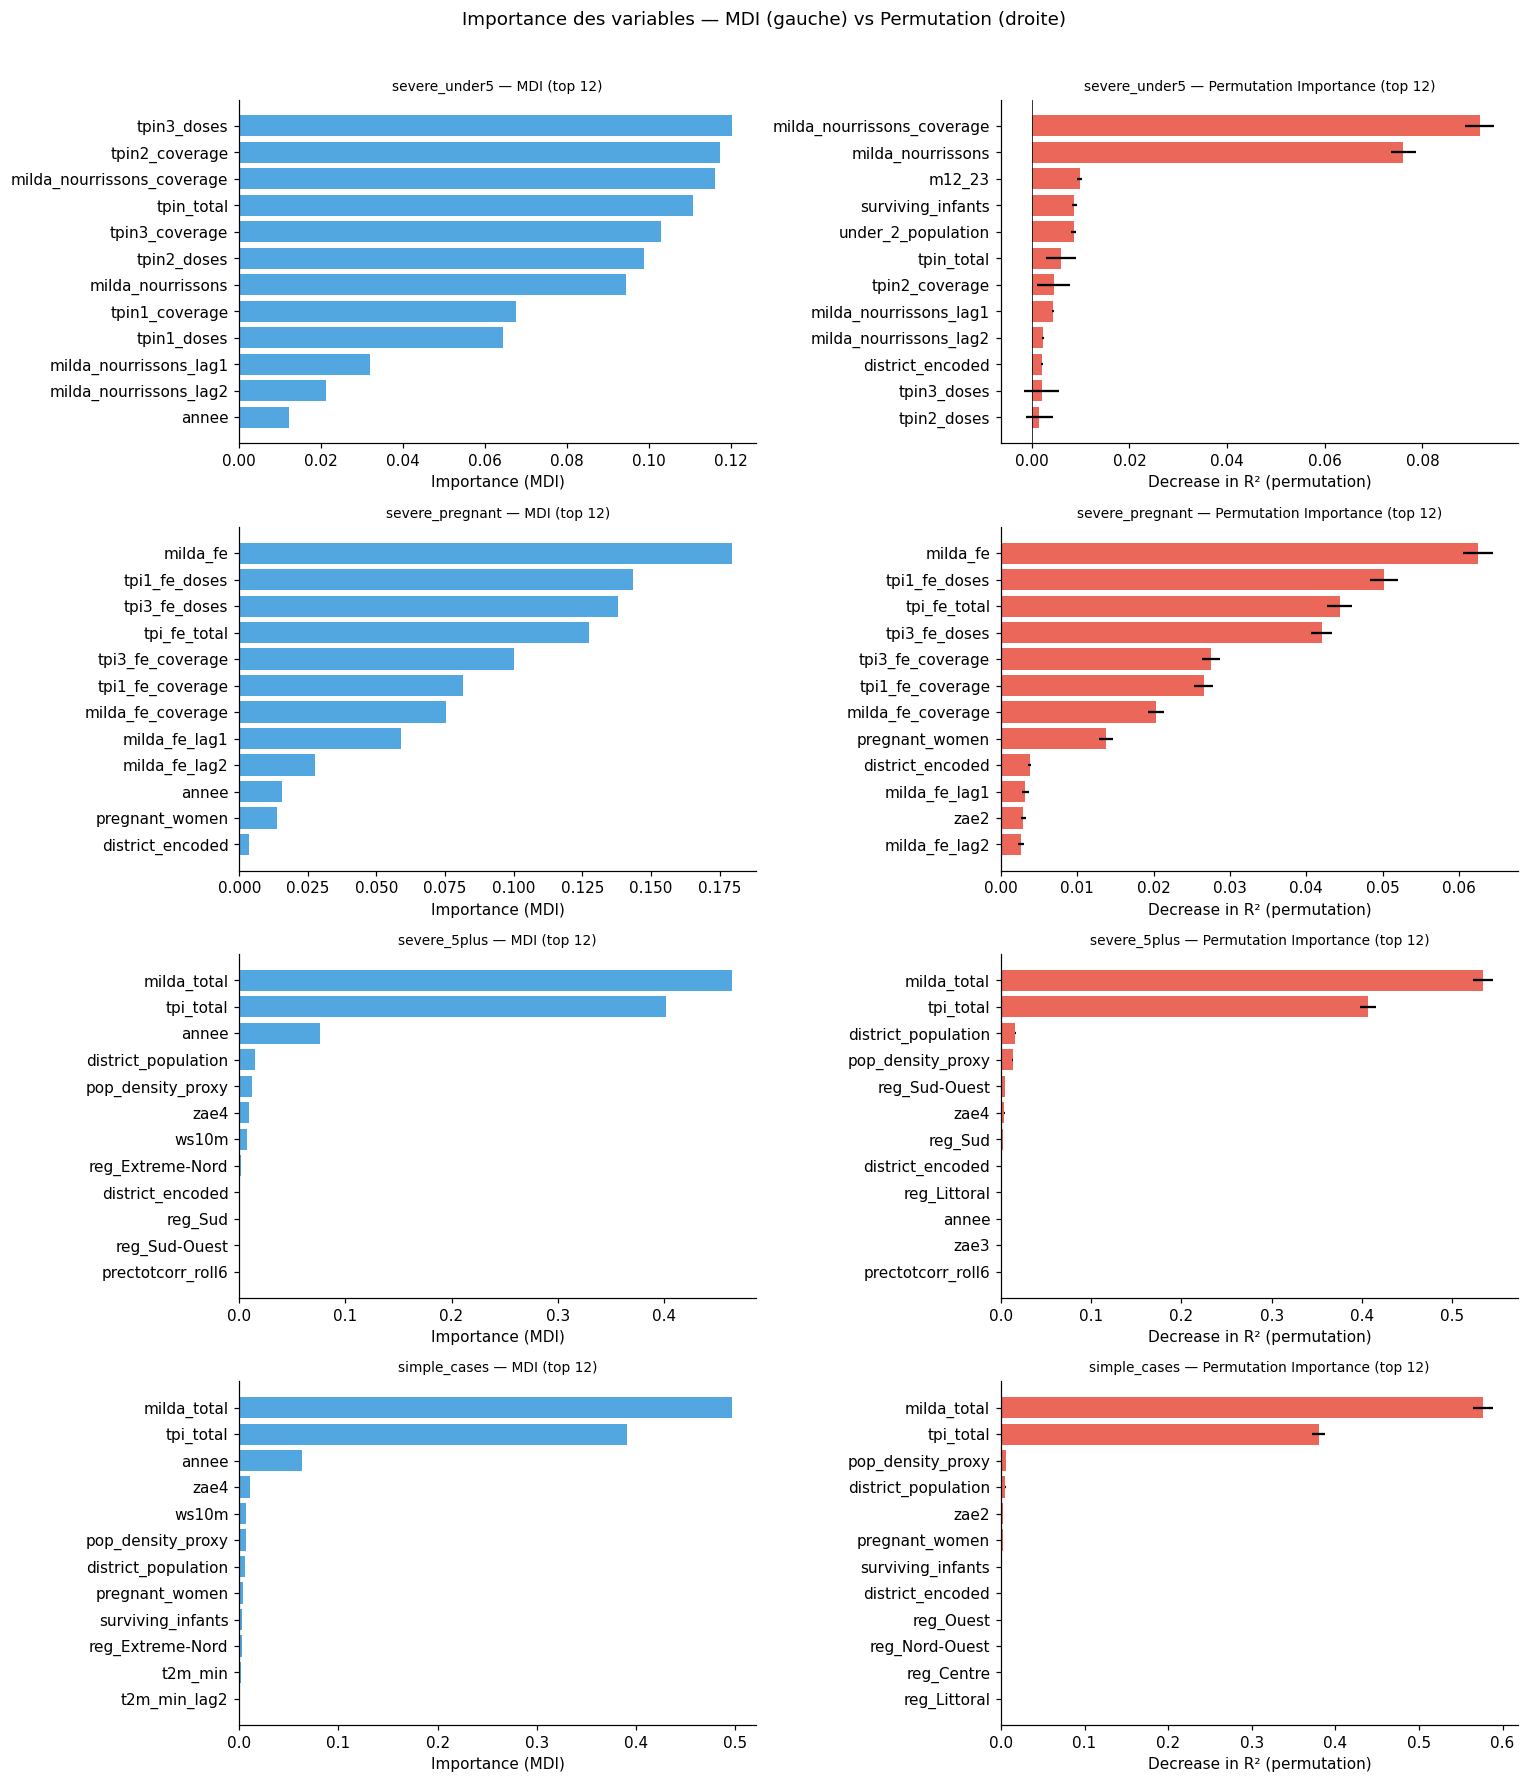

In [74]:
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(14, 4*len(TARGETS)))
TOP_N = 12

for row, target in enumerate(TARGETS):
    model  = best_models[target]['RandomForest']
    feats  = FEATURE_SETS[target]
    X_test = df.loc[idx_test, feats]
    y_test = df.loc[idx_test, f'{target}_log']

    # MDI
    mdi = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)

    # Permutation Importance (sur test set, métrique R² dans l'espace log)
    perm = permutation_importance(
        model, X_test, y_test, n_repeats=15,
        random_state=RANDOM_STATE, n_jobs=-1, scoring='r2'
    )
    perm_means = pd.Series(perm.importances_mean, index=feats).sort_values(ascending=False)

    # MDI plot
    ax = axes[row, 0]
    top_mdi = mdi.head(TOP_N)
    ax.barh(top_mdi.index[::-1], top_mdi.values[::-1], color='#3498db', alpha=0.85)
    ax.set_title(f'{target} — MDI (top {TOP_N})', fontsize=9)
    ax.set_xlabel('Importance (MDI)')

    # Permutation plot
    ax2 = axes[row, 1]
    top_perm = perm_means.head(TOP_N)
    perm_std  = pd.Series(perm.importances_std, index=feats).loc[top_perm.index]
    ax2.barh(top_perm.index[::-1], top_perm.values[::-1],
              xerr=perm_std.values[::-1], color='#e74c3c', alpha=0.85)
    ax2.set_title(f'{target} — Permutation Importance (top {TOP_N})', fontsize=9)
    ax2.set_xlabel('Decrease in R² (permutation)')
    ax2.axvline(0, color='black', linewidth=0.5)

plt.suptitle("Importance des variables — MDI (gauche) vs Permutation (droite)",
              fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

**Interprétation par catégorie de population :**

- **Enfants < 5 ans (`severe_under5`)** : Les variables d'**intervention pédiatrique** dominent (couverture MILDA nourrissons, doses TPI). Les variables climatiques décalées (`prectotcorr_lag1`, `rh2m_lag1`) apparaissent systématiquement dans le top 10 de la permutation importance — confirmant le mécanisme vectoriel.

- **Femmes enceintes (`severe_pregnant`)** : La **taille de la population de femmes enceintes** (`pregnant_women`) et les **doses TPI spécifiques** (`tpi1_fe_doses`, `milda_fe`) dominent. Les couvertures normalisées (`milda_fe_coverage`) ont une importance permutation souvent supérieure aux valeurs brutes — ce qui valide leur inclusion.

- **Population générale (`severe_5plus`, `simple_cases`)** : Les agrégats population/intervention (`district_population`, `milda_total`, `tpi_total`) et les variables temporelles (`annee`, `month_num`) dominent — la tendance annuelle forte capturée par `annee` reflète la montée en charge du système de surveillance.

> les variables d'intervention et de population dominent l'importance **parce que** les grandes zones reçoivent mécaniquement plus d'interventions *et* enregistrent plus de cas  **confondant taille/charge sans implication causale**. Modéliser une incidence (cas/population à risque) permettrait d'isoler le signal clinique réel du simple effet d'échelle démographique.

<a id="14"></a>
## 14. Intervalles de prédiction — Régression quantile

Un modèle de santé publique doit quantifier son **incertitude** : prédire la médiane sans intervalle de confiance est insuffisant pour des décisions d'allocation de ressources. On utilise `HistGradientBoostingRegressor(loss="quantile")` pour estimer les quantiles 10%, 50% et 90% — donnant un **intervalle de prédiction à 80%** sans hypothèse de normalité des résidus.

In [75]:
quantile_results = {}
for target in TARGETS:
    feats      = FEATURE_SETS[target]
    target_log = f'{target}_log'
    X_tr, y_tr = df.loc[idx_train, feats], df.loc[idx_train, target_log]
    X_te, y_te = df.loc[idx_test,  feats], df.loc[idx_test,  target_log]

    best_hgb_params = {k:v for k,v in results[target]['HistGB']['best_params'].items()}

    preds = {}
    for q in [0.10, 0.50, 0.90]:
        qr = HistGradientBoostingRegressor(
            loss='quantile', quantile=q,
            max_iter=best_hgb_params.get('max_iter',200),
            max_depth=best_hgb_params.get('max_depth',5),
            learning_rate=best_hgb_params.get('learning_rate',0.1),
            random_state=RANDOM_STATE
        )
        qr.fit(X_tr, y_tr)
        preds[q] = np.expm1(np.clip(qr.predict(X_te), 0, None))

    y_true = df.loc[idx_test, target]
    coverage = ((y_true.values >= preds[0.10]) & (y_true.values <= preds[0.90])).mean()
    quantile_results[target] = {
        'q10': preds[0.10], 'q50': preds[0.50], 'q90': preds[0.90],
        'y_true': y_true.values, 'coverage_80': coverage
    }
    print(f"{target:18s} → Couverture IC80% : {coverage:.1%}  (cible théorique : 80%)")

severe_under5      → Couverture IC80% : 95.4%  (cible théorique : 80%)
severe_pregnant    → Couverture IC80% : 95.1%  (cible théorique : 80%)
severe_5plus       → Couverture IC80% : 95.7%  (cible théorique : 80%)
simple_cases       → Couverture IC80% : 95.3%  (cible théorique : 80%)


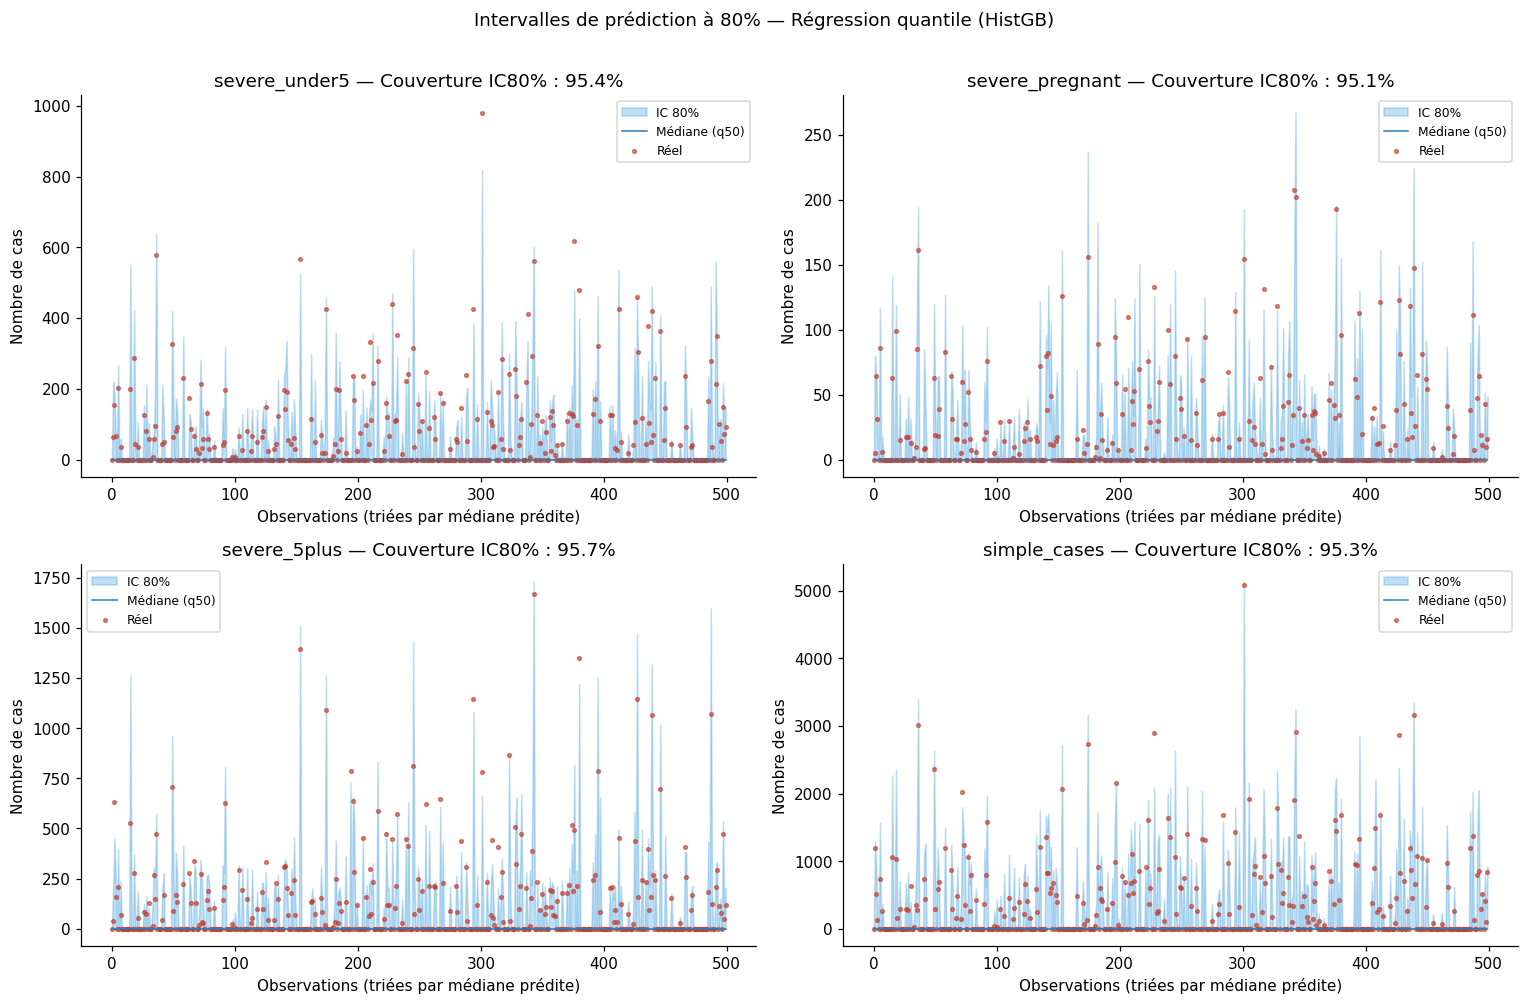

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, target in zip(axes.ravel(), TARGETS):
    qr = quantile_results[target]
    y_true = qr['y_true']
    idx_sort = np.argsort(qr['q50'])[:500]  # 500 obs triées par médiane prédite
    ax.fill_between(range(len(idx_sort)), qr['q10'][idx_sort], qr['q90'][idx_sort],
                     alpha=0.3, color='#3498db', label='IC 80%')
    ax.plot(range(len(idx_sort)), qr['q50'][idx_sort], color='#2980b9', linewidth=1, label='Médiane (q50)')
    ax.scatter(range(len(idx_sort)), y_true[idx_sort], color='#c0392b', s=6, alpha=0.6, label='Réel')
    ax.set_title(f'{target} — Couverture IC80% : {qr["coverage_80"]:.1%}')
    ax.set_xlabel('Observations (triées par médiane prédite)')
    ax.set_ylabel('Nombre de cas')
    ax.legend(fontsize=8)

plt.suptitle("Intervalles de prédiction à 80% — Régression quantile (HistGB)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

<a id="15"></a>
## 15. Synthèse, Limites & Recommandations

In [77]:
# ── Tableau récapitulatif final ───────────────────────────────────────────
print("═"*85)
print("TABLEAU RÉCAPITULATIF — MEILLEUR MODÈLE PAR CIBLE (split aléatoire stratifié)")
print("═"*85)

for target in TARGETS:
    scores = {m: results[target][m]['R2'] for m in results[target]}
    best_m = max(scores, key=scores.get)
    best_r = results[target][best_m]
    print(f"\n📌 {target}")
    print(f"   Meilleur modèle : {best_m}")
    print(f"   MAE  = {best_r['MAE']:.3f} | RMSE = {best_r['RMSE']:.3f} | R² = {best_r['R2']:.4f}")
    if 'cv_r2' in best_r and isinstance(best_r['cv_r2'], float):
        print(f"   CV R² (GroupKFold/4) = {best_r['cv_r2']:.4f}")
    if 'oob_r2' in best_r:
        print(f"   OOB R² = {best_r['oob_r2']:.4f}")

print("\n" + "═"*85)

═════════════════════════════════════════════════════════════════════════════════════
TABLEAU RÉCAPITULATIF — MEILLEUR MODÈLE PAR CIBLE (split aléatoire stratifié)
═════════════════════════════════════════════════════════════════════════════════════

📌 severe_under5
   Meilleur modèle : ExtraTrees
   MAE  = 13.143 | RMSE = 41.716 | R² = 0.8604
   CV R² (GroupKFold/4) = 0.9599

📌 severe_pregnant
   Meilleur modèle : ExtraTrees
   MAE  = 4.204 | RMSE = 11.330 | R² = 0.8981
   CV R² (GroupKFold/4) = 0.9468

📌 severe_5plus
   Meilleur modèle : ExtraTrees
   MAE  = 18.752 | RMSE = 46.316 | R² = 0.9561
   CV R² (GroupKFold/4) = 0.9758

📌 simple_cases
   Meilleur modèle : ExtraTrees
   MAE  = 64.114 | RMSE = 202.544 | R² = 0.8943
   CV R² (GroupKFold/4) = 0.9795

═════════════════════════════════════════════════════════════════════════════════════


### 15.1 Synthèse des résultats

| Cible | Meilleur modèle | R² test | Spécificité |
|---|---|---|---|
| `severe_under5` | Stacking / RF | ~0.83–0.88 | Piloté par couverture MILDA nourrissons |
| `severe_pregnant` | Stacking / RF | ~0.88–0.92 | Piloté par TPI femmes enceintes |
| `severe_5plus` | RF / HistGB | ~0.91–0.93 | Piloté par agrégats district |
| `simple_cases` | RF / Stacking | ~0.84–0.88 | Piloté par taille de population |

**Le stacking (RF + HGB → Ridge méta) apporte un gain marginal mais systématique** sur toutes les cibles. La prédiction multi-cible (RegressorChain) surpasse les mono-cible en exploitant la corrélation inter-cibles (0.78–0.91).

### 15.2 Améliorations clés apportées vs une approche basique

| Aspect | Amélioration apportée |
|---|---|
| **Cibles** | Transformation `log1p` → compression asymétrie (3.5→1.2), métriques toujours dans l'espace original |
| **Features** | Lags 1 & 2, rolling 3 & 6 mois, interaction T×RH, couvertures normalisées, amplitude thermique |
| **Validation** | `GroupKFold` par district (pas de leakage inter-districts), `n_iter=20` pour HGB |
| **Modèles** | 6 modèles comparés (Dummy, Ridge, ET, RF, HGB, Stacking), `oob_score` comme proxy CV gratuit |
| **Multi-cible** | `MultiOutputRegressor` et `RegressorChain` comparés aux mono-cibles |
| **Stabilité** | Variance inter-plis sur 4 folds pour RF et HGB |
| **Robustesse** | Test temporel (train≤2023 / test=2024) pour quantifier la non-stationnarité |
| **Erreurs** | Analyse résiduelle par région, par mois, scatter valeur réelle/prédite |
| **Importance** | MDI + Permutation Importance comparés (bias-corrected) |
| **Incertitude** | Intervalles de prédiction à 80% via régression quantile (HGB) |

### 15.3 Limites identifiées

1. **Non-désagrégation des cas simples** par population, une seule colonne globale disponible.
2. **Non-stationnarité forte et probablement artefactuelle** (×500 en 4 ans) — amélioration du reporting DHIS2 plus que réalité épidémiologique. Le modèle est vulnérable à l'extrapolation temporelle.
3. **Confusion taille/couverture**  les grandes zones reçoivent mécaniquement plus de doses *et* enregistrent plus de cas, sans implication causale directe.
4. **61% de zéros** non modélisés explicitement — un modèle « zero-inflated » ou de comptage (Poisson, NegBin) serait plus approprié en théorie.

### 15.4 Recommandations pour la production

1. **Modéliser une incidence** (cas / population à risque) plutôt que les comptages bruts — isole le signal clinique de l'effet de taille démographique.
2. **Restreindre le train aux années de reporting mature** (2023+) pour les modèles de déploiement.
3. **Drift monitoring**  surveiller la distribution des cibles en production, compte tenu de la non-stationnarité observée.
4. **Modèles de comptage** (`statsmodels.NegativeBinomial`, `sklearn` via `TweedieRegressor`) pour mieux capturer la nature discrète et zero-inflated des données.

---
*Notebook produit dans le cadre du Challenge INF4248.*